# **Heart Failure Clinical Records Dataset**

## Deskripsi Singkat
Dataset ini berisi catatan medis dari 299 pasien dengan kondisi gagal jantung. Data digunakan untuk menganalisis faktor-faktor klinis yang berhubungan dengan kematian akibat gagal jantung, serta sering digunakan dalam penelitian machine learning untuk prediksi risiko kematian.

- **Sumber**: [UCI Machine Learning Repository - Heart Failure Clinical Records](https://archive.ics.uci.edu/ml/datasets/Heart+failure+clinical+records)
- **Format**: CSV (Comma-Separated Values)
- **Jumlah Sampel**: 299 pasien
- **Jumlah Fitur**: 13 kolom (12 fitur + 1 label)

## Label
- `DEATH_EVENT`: Status kematian pasien selama masa tindak lanjut  
  - `0` = Pasien hidup  
  - `1` = Pasien meninggal

## Deskripsi Kolom
| Kolom                     | Deskripsi                                                                 |
|--------------------------|---------------------------------------------------------------------------|
| `age`                    | Usia pasien (tahun)                                                       |
| `anaemia`                | Anemia (0 = Tidak, 1 = Ya)                                                |
| `high_blood_pressure`    | Riwayat tekanan darah tinggi (0 = Tidak, 1 = Ya)                          |
| `creatinine_phosphokinase` | Level enzim CPK dalam darah (mcg/L)                                   |
| `diabetes`               | Riwayat diabetes (0 = Tidak, 1 = Ya)                                      |
| `ejection_fraction`      | Persentase darah yang dipompa jantung setiap detak (%)                   |
| `platelets`              | Jumlah platelet dalam darah (kiloplatelets/mL)                            |
| `serum_creatinine`       | Level kreatinin serum (mg/dL)                                             |
| `serum_sodium`           | Level natrium serum (mEq/L)                                               |
| `sex`                    | Jenis kelamin (0 = Perempuan, 1 = Laki-laki)                              |
| `smoking`                | Status merokok (0 = Tidak, 1 = Ya)                                        |
| `time`                   | Lama tindak lanjut (hari)                                                 |


# **IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.ticker as mtick
import math
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
# %%
# Menekan warning yang tidak perlu
warnings.filterwarnings('ignore')
# %%
# Set style plot
#plt.style.use('seaborn-whitegrid') # This style is deprecated
plt.style.use('seaborn-v0_8-whitegrid') # Use this style instead
# or
# sns.set_style('whitegrid') # You can also use seaborn directly to set the style

# **Load Data**

In [ ]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [ ]:
df.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


# **Pemahaman Dataset**

In [ ]:
print("\n--- Informasi Dataset ---")
print(f"Jumlah baris dan kolom: {df.shape}")
print(f"Jumlah total elemen: {df.size}")


--- Informasi Dataset ---
Jumlah baris dan kolom: (299, 13)
Jumlah total elemen: 3887


In [ ]:
print("\n--- Deskripsi Statistik ---")
(df.describe().T)


--- Deskripsi Statistik ---


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [ ]:
print("\n--- Tipe Data ---")
(df.dtypes)


--- Tipe Data ---


,0
age,float64
anaemia,int64
creatinine_phosphokinase,int64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64


In [ ]:
(df.columns.tolist())

['age',
 'anaemia',
 'creatinine_phosphokinase',
 'diabetes',
 'ejection_fraction',
 'high_blood_pressure',
 'platelets',
 'serum_creatinine',
 'serum_sodium',
 'sex',
 'smoking',
 'time',
 'DEATH_EVENT']

## **Pengecekan nilai yang hilang (missing values)**


In [ ]:
print("\n--- Cek Nilai Hilang ---")
missing_values = df.isnull().sum()
print(missing_values)
if missing_values.sum() == 0:
    print("Tidak ada nilai yang hilang dalam dataset.")
else:
    print(f"Terdapat total {missing_values.sum()} nilai yang hilang dalam dataset.")


--- Cek Nilai Hilang ---
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64
Tidak ada nilai yang hilang dalam dataset.


## **Pengecekan data duplikat**


In [ ]:
print("\n--- Cek Data Duplikat ---")
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")


--- Cek Data Duplikat ---
Jumlah data duplikat: 0


## **Deskripsi detail fitur-fitur di dataset**


In [ ]:
print("\n--- Deskripsi Fitur Dataset ---")
feature_descriptions = {
    'age': 'Usia pasien dalam tahun',
    'anaemia': 'Penurunan sel darah merah (0: tidak, 1: ya)',
    'creatinine_phosphokinase': 'Level enzim CPK dalam darah (mcg/L)',
    'diabetes': 'Diabetes (0: tidak, 1: ya)',
    'ejection_fraction': 'Persentase darah yang dipompa keluar jantung saat kontraksi (%)',
    'high_blood_pressure': 'Hipertensi (0: tidak, 1: ya)',
    'platelets': 'Trombosit dalam darah (kiloplatelets/mL)',
    'serum_creatinine': 'Level serum kreatinin dalam darah (mg/dL)',
    'serum_sodium': 'Level serum sodium dalam darah (mEq/L)',
    'sex': 'Jenis kelamin (0: perempuan, 1: laki-laki)',
    'smoking': 'Merokok (0: tidak, 1: ya)',
    'time': 'Periode tindak lanjut (hari)',
    'DEATH_EVENT': 'Kematian selama periode tindak lanjut (0: tidak, 1: ya)'
}

for feature, description in feature_descriptions.items():
    print(f"{feature}: {description}")


--- Deskripsi Fitur Dataset ---
age: Usia pasien dalam tahun
anaemia: Penurunan sel darah merah (0: tidak, 1: ya)
creatinine_phosphokinase: Level enzim CPK dalam darah (mcg/L)
diabetes: Diabetes (0: tidak, 1: ya)
ejection_fraction: Persentase darah yang dipompa keluar jantung saat kontraksi (%)
high_blood_pressure: Hipertensi (0: tidak, 1: ya)
platelets: Trombosit dalam darah (kiloplatelets/mL)
serum_creatinine: Level serum kreatinin dalam darah (mg/dL)
serum_sodium: Level serum sodium dalam darah (mEq/L)
sex: Jenis kelamin (0: perempuan, 1: laki-laki)
smoking: Merokok (0: tidak, 1: ya)
time: Periode tindak lanjut (hari)
DEATH_EVENT: Kematian selama periode tindak lanjut (0: tidak, 1: ya)


## **Distribusi target (DEATH_EVENT)**

In [ ]:
print("\n--- Distribusi Target (DEATH_EVENT) ---")
death_counts = df['DEATH_EVENT'].value_counts()
print(death_counts)
print(f"Persentase kematian: {(death_counts[1] / len(df) * 100):.2f}%")
print(f"Persentase bertahan: {(death_counts[0] / len(df) * 100):.2f}%")


--- Distribusi Target (DEATH_EVENT) ---
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
Persentase kematian: 32.11%
Persentase bertahan: 67.89%


# **Eksplorasi Data dan Pra-pemrosesan**

## **Visualisasi distribusi target**


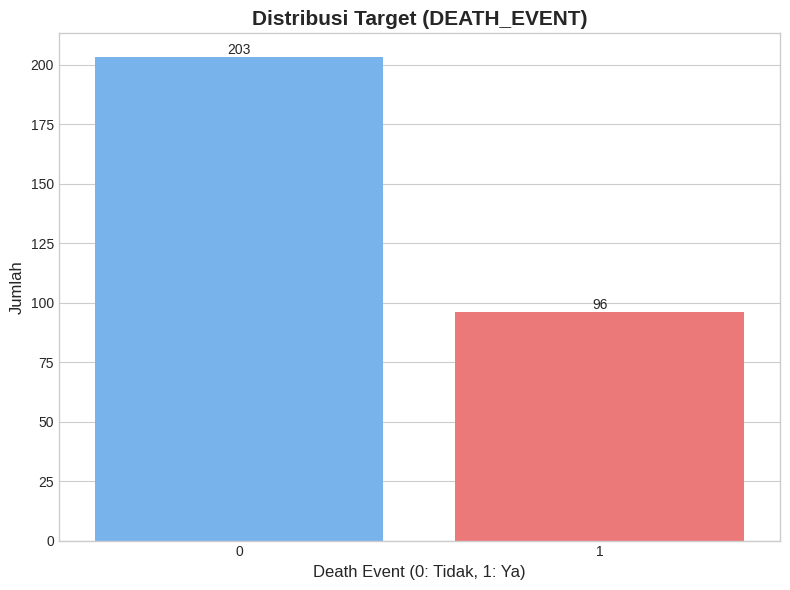

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='DEATH_EVENT', data=df, palette=['#66b3ff', '#ff6666'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribusi Target (DEATH_EVENT)', fontsize=15, fontweight='bold')
plt.xlabel('Death Event (0: Tidak, 1: Ya)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## **Analisis fitur kategorik**



--- Analisis Fitur Kategorik ---

Distribusi anaemia:
anaemia
0    170
1    129
Name: count, dtype: int64
Persentase 1: 43.14%


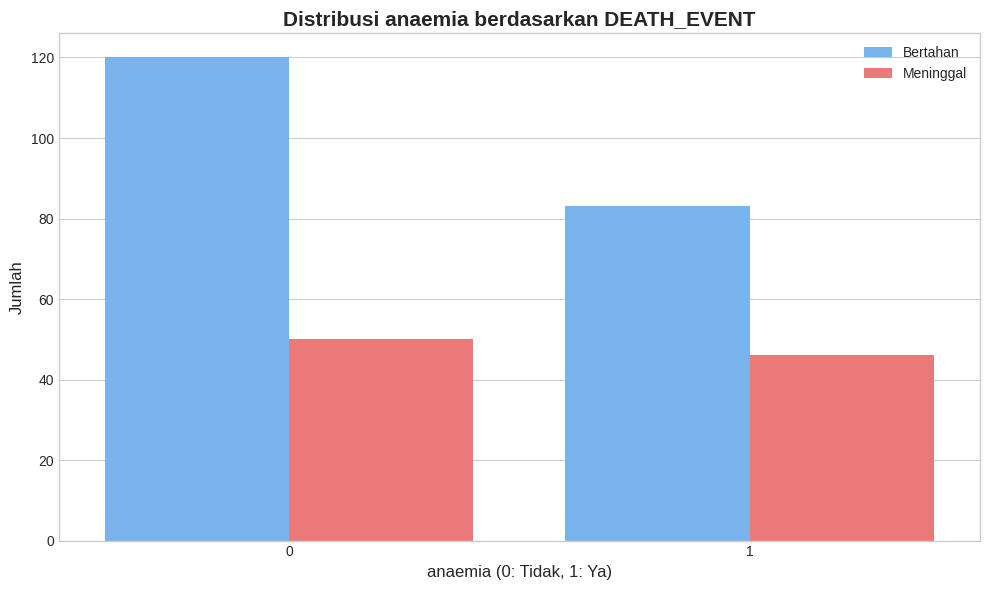


Distribusi diabetes:
diabetes
0    174
1    125
Name: count, dtype: int64
Persentase 1: 41.81%


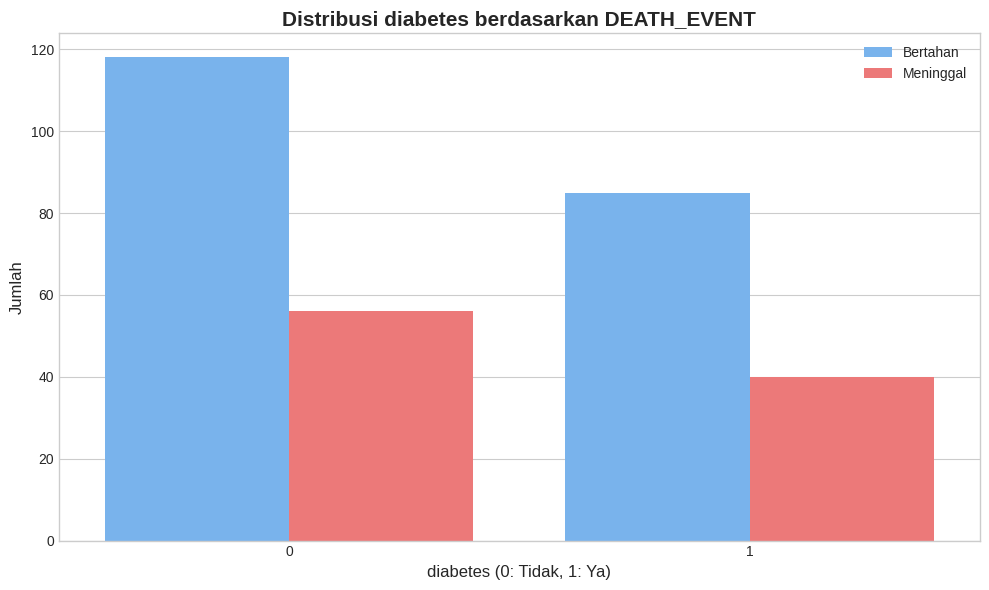


Distribusi high_blood_pressure:
high_blood_pressure
0    194
1    105
Name: count, dtype: int64
Persentase 1: 35.12%


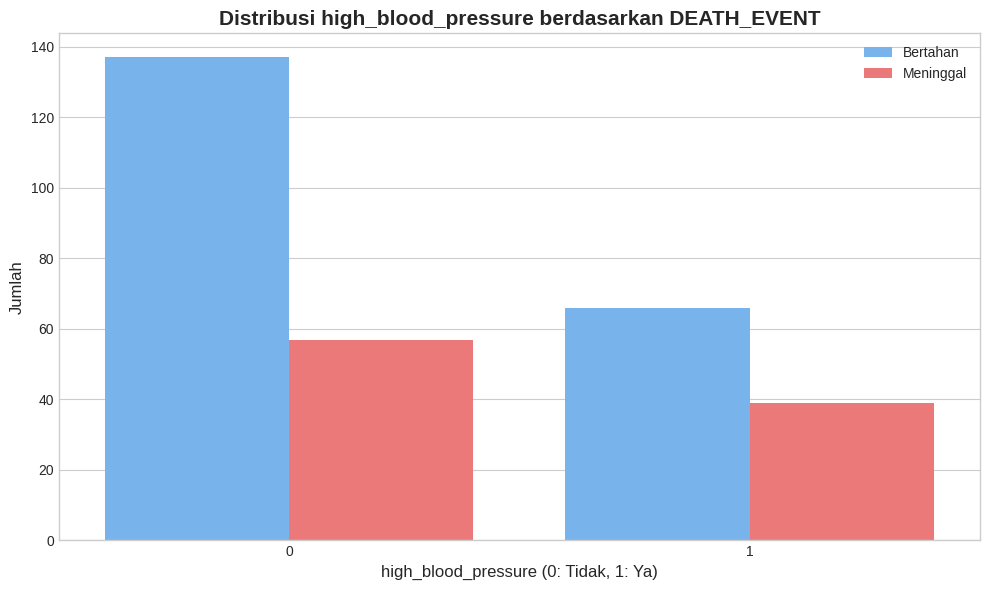


Distribusi sex:
sex
1    194
0    105
Name: count, dtype: int64
Persentase 1: 64.88%


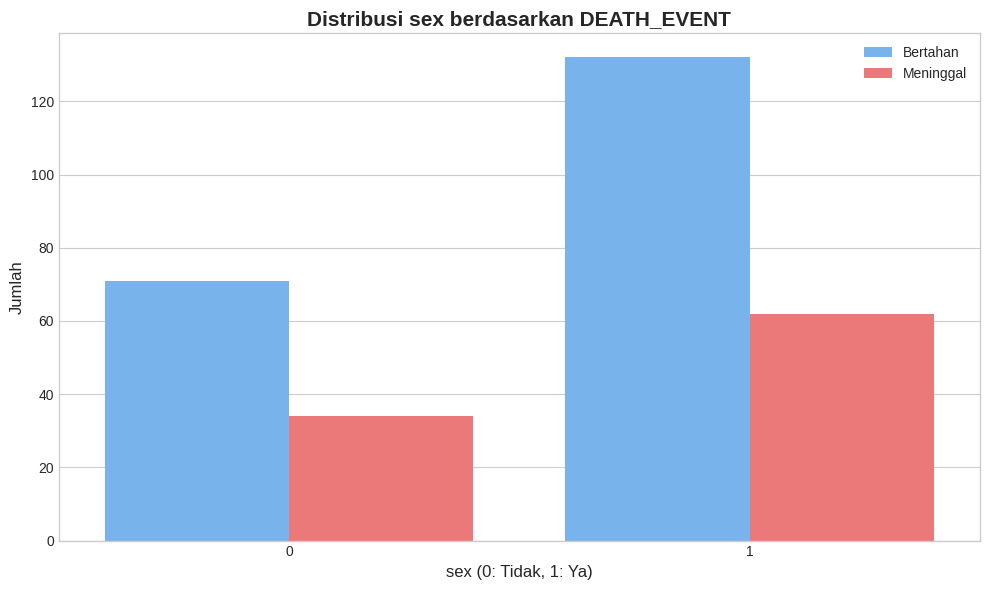


Distribusi smoking:
smoking
0    203
1     96
Name: count, dtype: int64
Persentase 1: 32.11%


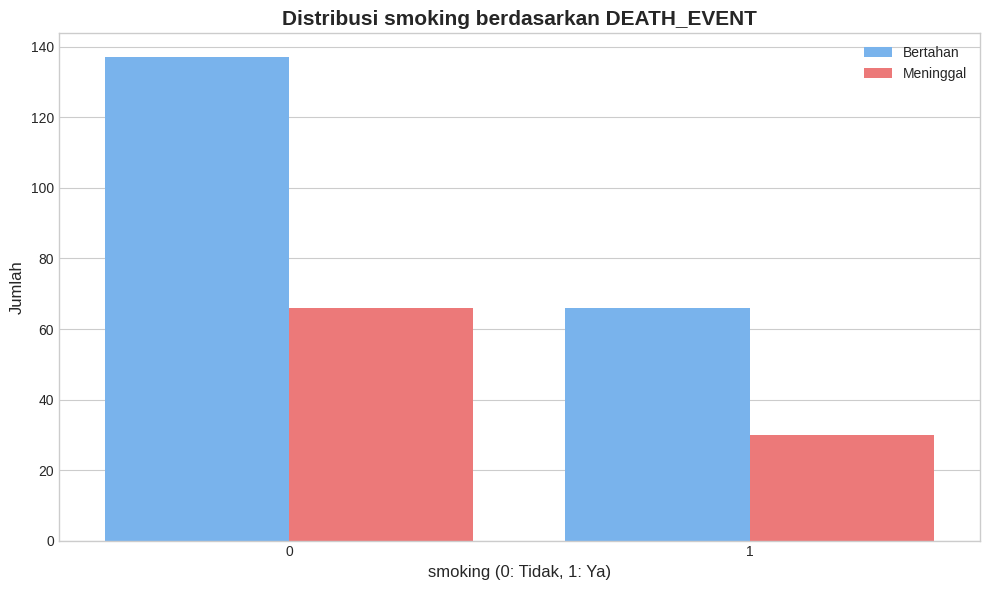

In [ ]:
print("\n--- Analisis Fitur Kategorik ---")
categorical_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']
for feature in categorical_features:
    if feature != 'DEATH_EVENT':
        print(f"\nDistribusi {feature}:")
        print(df[feature].value_counts())
        print(f"Persentase 1: {(df[feature].mean() * 100):.2f}%")

        # Visualisasi fitur kategorik vs target
        plt.figure(figsize=(10, 6))
        sns.countplot(x=feature, hue='DEATH_EVENT', data=df, palette=['#66b3ff', '#ff6666'])
        plt.title(f'Distribusi {feature} berdasarkan DEATH_EVENT', fontsize=15, fontweight='bold')
        plt.xlabel(f'{feature} (0: Tidak, 1: Ya)', fontsize=12)
        plt.ylabel('Jumlah', fontsize=12)
        plt.legend(['Bertahan', 'Meninggal'])
        plt.tight_layout()
        plt.savefig(f'{feature}_vs_target.png', dpi=300, bbox_inches='tight')
        plt.show()

## **Analisis fitur numerik**


--- Analisis Fitur Numerik ---


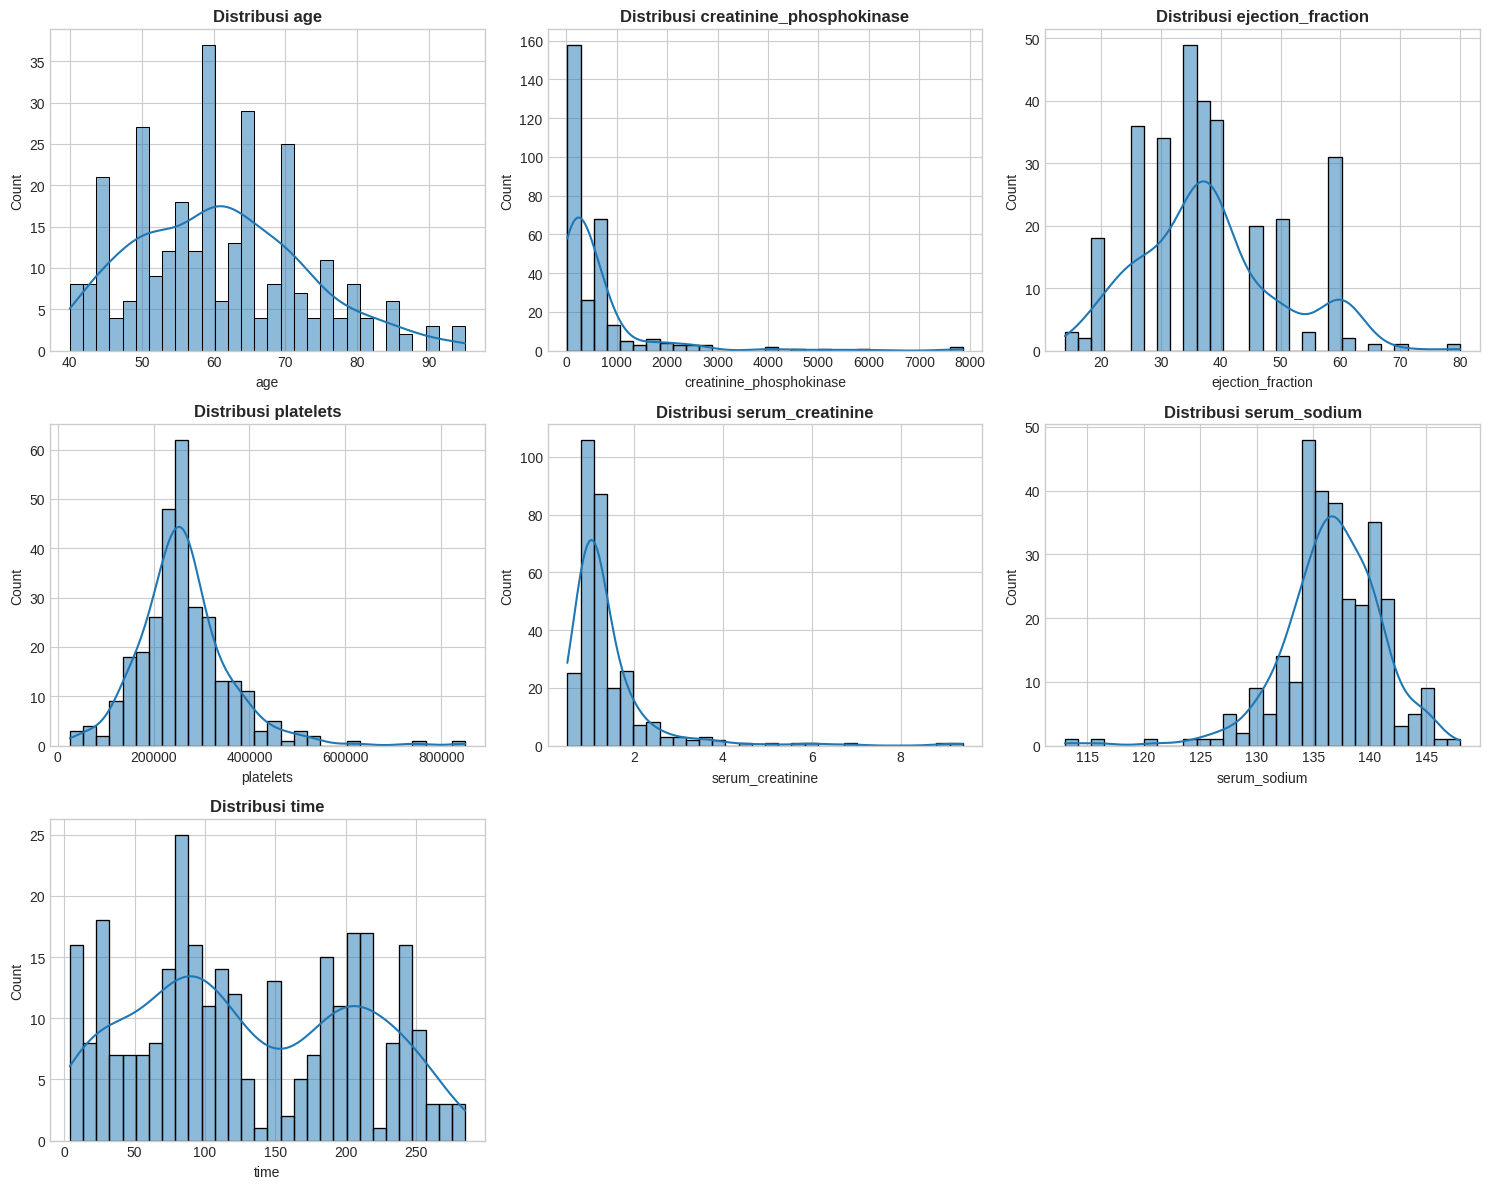

In [ ]:
print("\n--- Analisis Fitur Numerik ---")
numerical_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                      'platelets', 'serum_creatinine', 'serum_sodium', 'time']

# Visualisasi distribusi fitur numerik dengan histogram
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribusi {feature}', fontsize=12, fontweight='bold')
    plt.tight_layout()
plt.savefig('numerical_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## **Visualisasi boxplot untuk fitur numerik berdasarkan target**

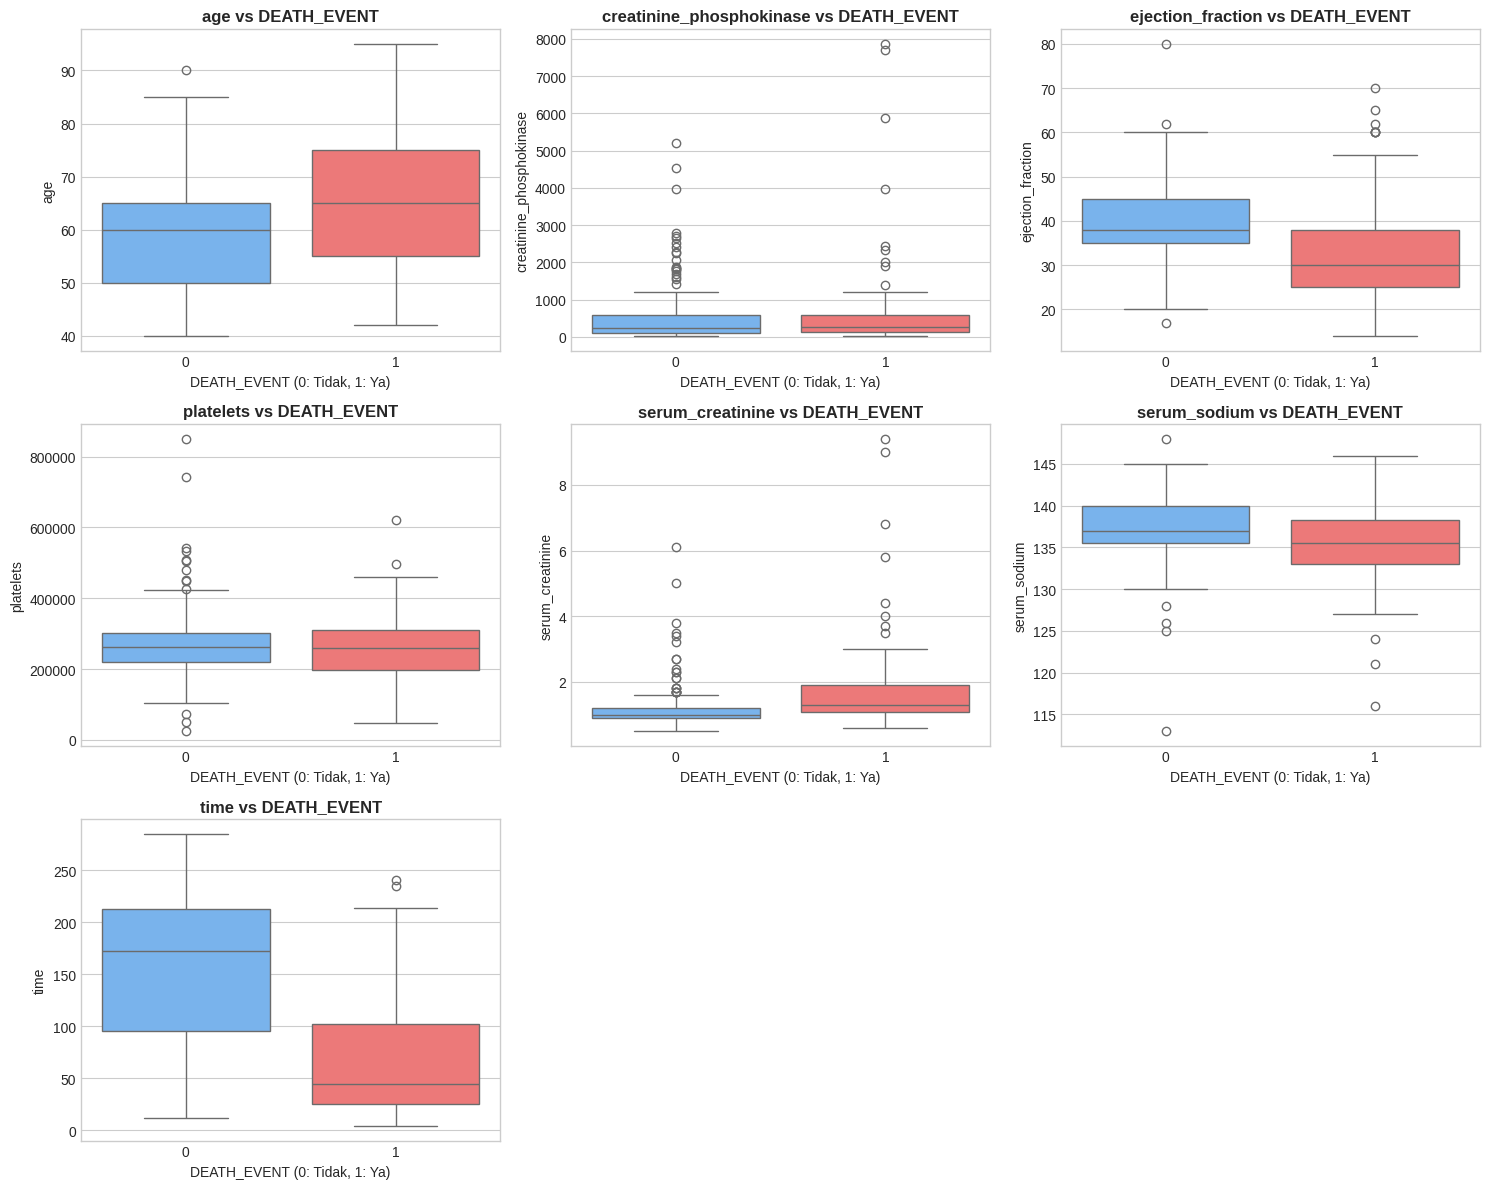

In [ ]:
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='DEATH_EVENT', y=feature, data=df, palette=['#66b3ff', '#ff6666'])
    plt.title(f'{feature} vs DEATH_EVENT', fontsize=12, fontweight='bold')
    plt.xlabel('DEATH_EVENT (0: Tidak, 1: Ya)', fontsize=10)
    plt.tight_layout()
plt.savefig('numerical_features_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## **Visualisasi distribusi fitur numerik berdasarkan target dengan KDE plot**


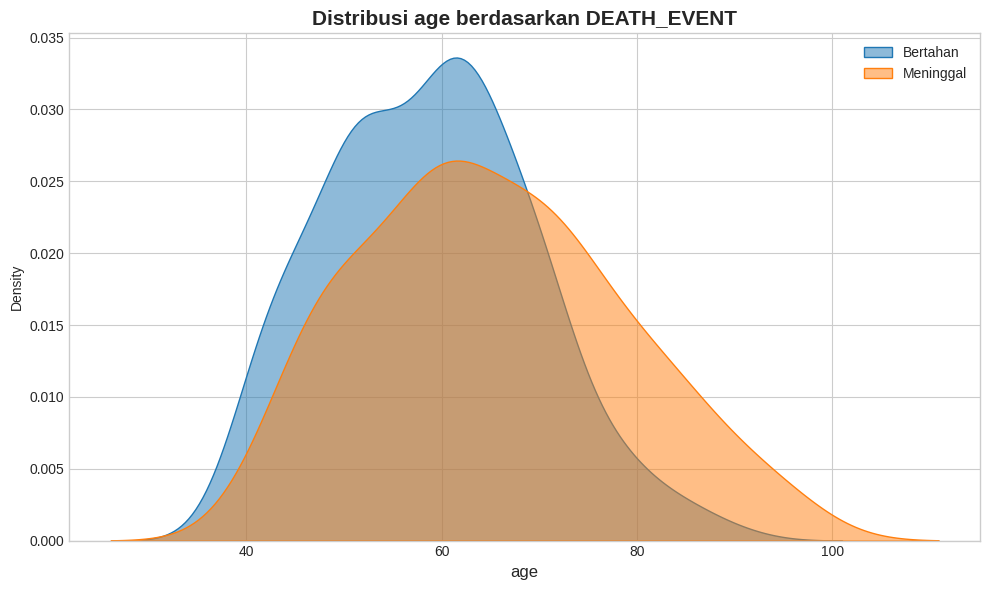

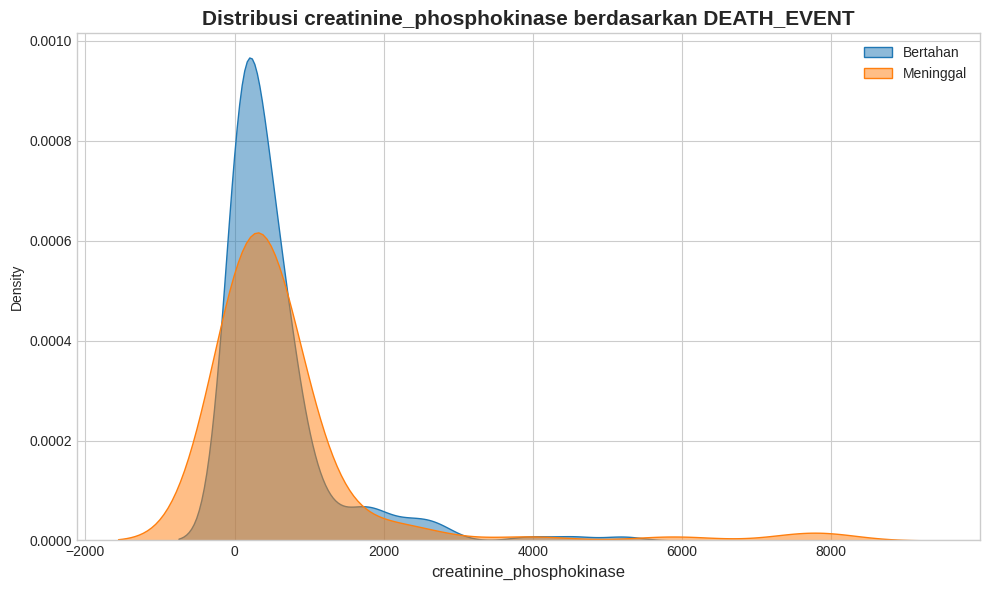

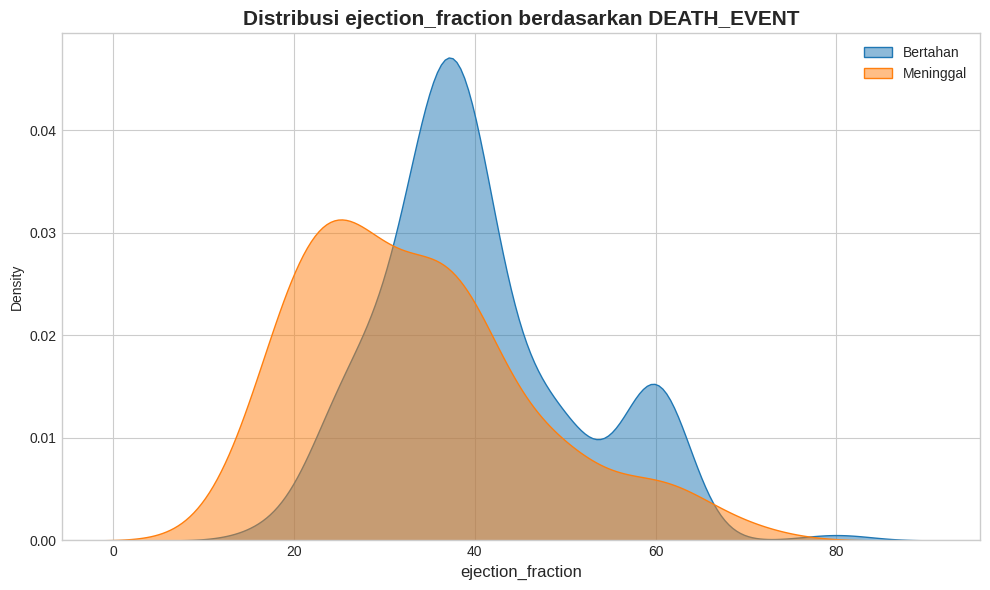

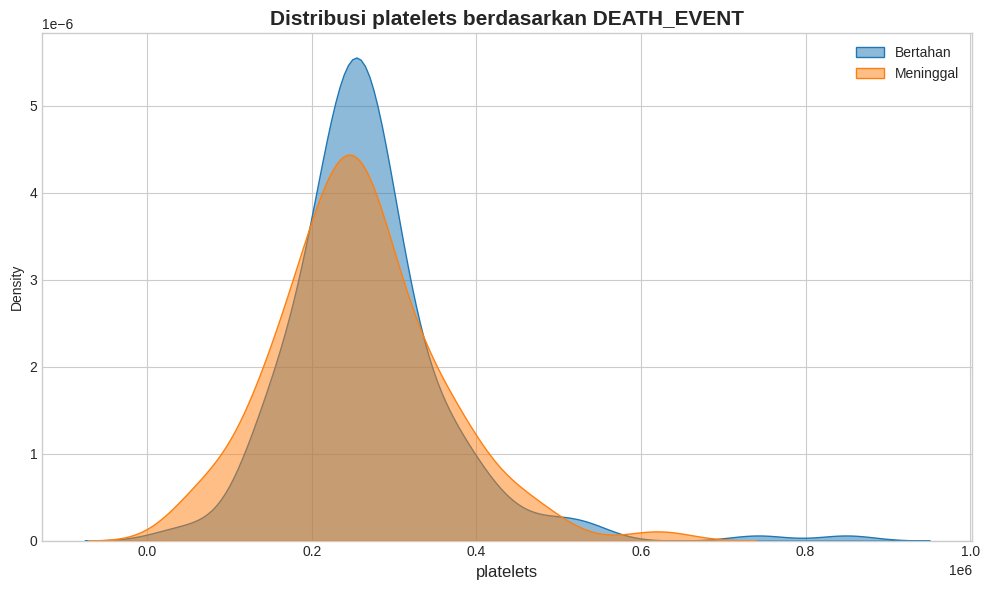

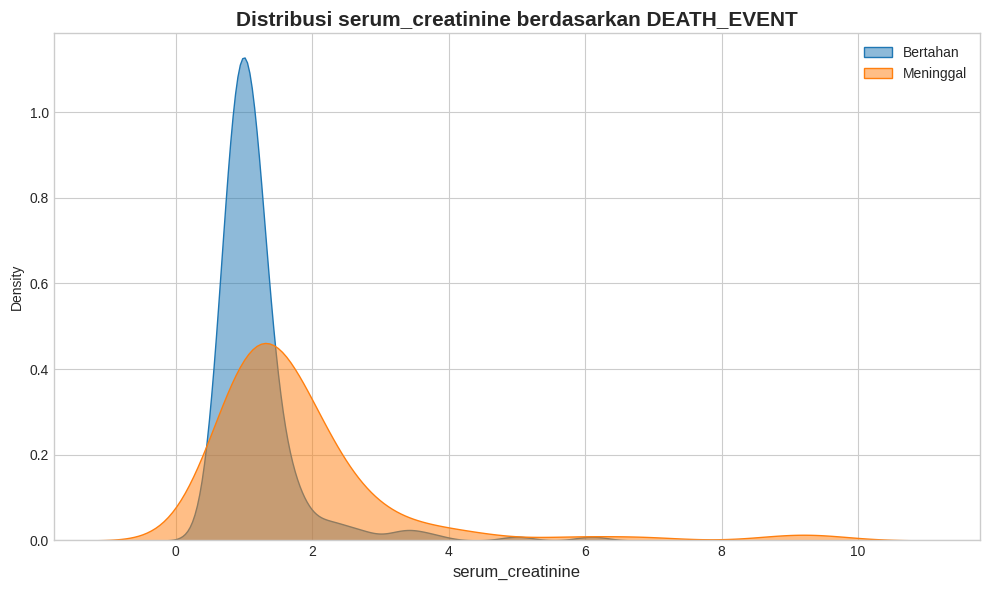

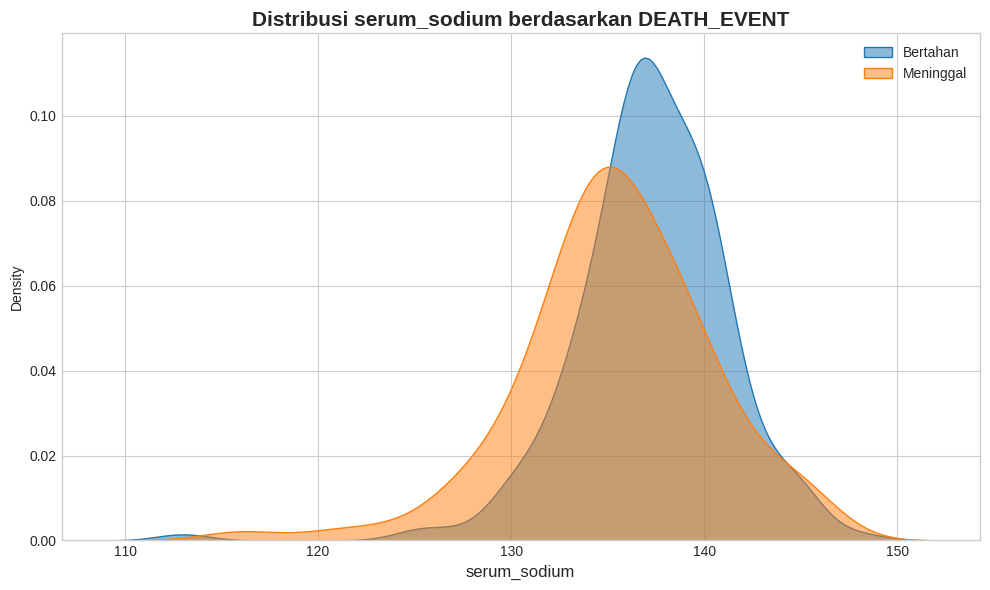

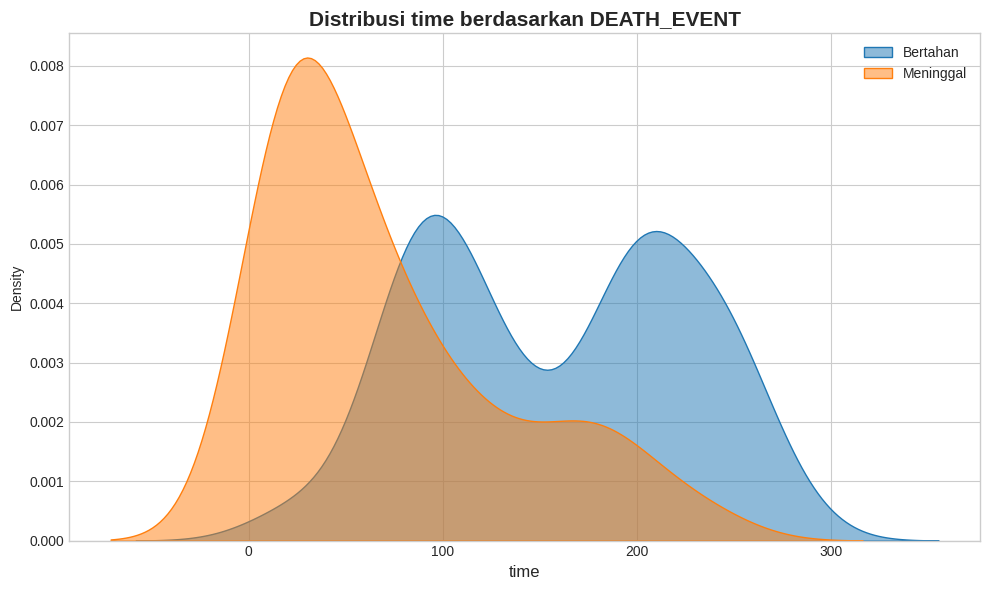

In [ ]:
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df[df['DEATH_EVENT'] == 0][feature], label='Bertahan', fill=True, alpha=0.5)
    sns.kdeplot(df[df['DEATH_EVENT'] == 1][feature], label='Meninggal', fill=True, alpha=0.5)
    plt.title(f'Distribusi {feature} berdasarkan DEATH_EVENT', fontsize=15, fontweight='bold')
    plt.xlabel(feature, fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{feature}_kde.png', dpi=300, bbox_inches='tight')
    plt.show()

## **Analisis korelasi**


In [ ]:
print("\n--- Analisis Korelasi ---")
correlation_matrix = df.corr()
print("\nKorelasi dengan DEATH_EVENT:")
print(correlation_matrix['DEATH_EVENT'].sort_values(ascending=False))


--- Analisis Korelasi ---

Korelasi dengan DEATH_EVENT:
DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64


## **Heatmap korelasi**


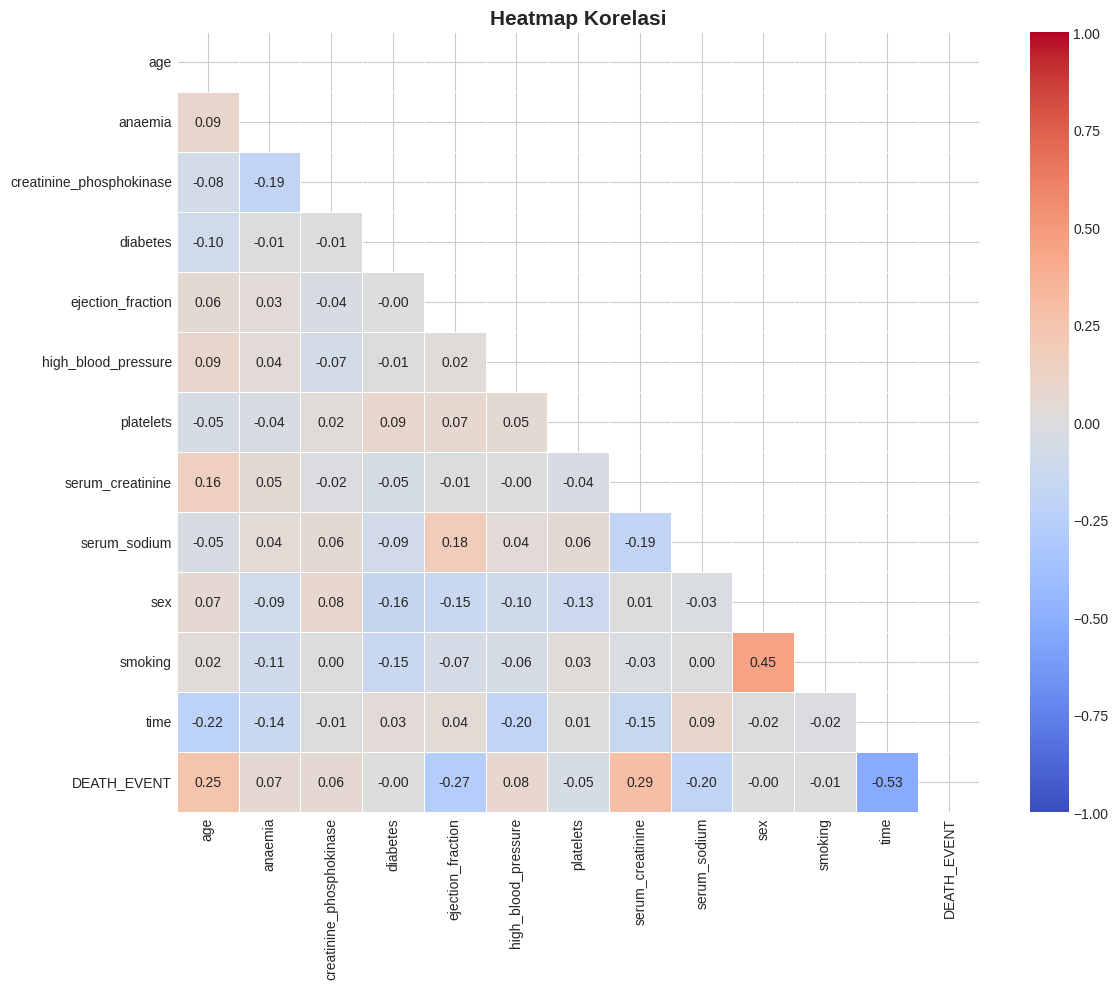

In [ ]:
plt.figure(figsize=(12, 10))
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## **Analisis outliers dengan IQR**


In [ ]:
print("\n--- Analisis Outliers ---")
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
    print(f"{feature}: {len(outliers)} outliers ({(len(outliers)/len(df)*100):.2f}%)")


--- Analisis Outliers ---
age: 0 outliers (0.00%)
creatinine_phosphokinase: 29 outliers (9.70%)
ejection_fraction: 2 outliers (0.67%)
platelets: 21 outliers (7.02%)
serum_creatinine: 29 outliers (9.70%)
serum_sodium: 4 outliers (1.34%)
time: 0 outliers (0.00%)


## **Visualisasi outliers dengan boxplot**


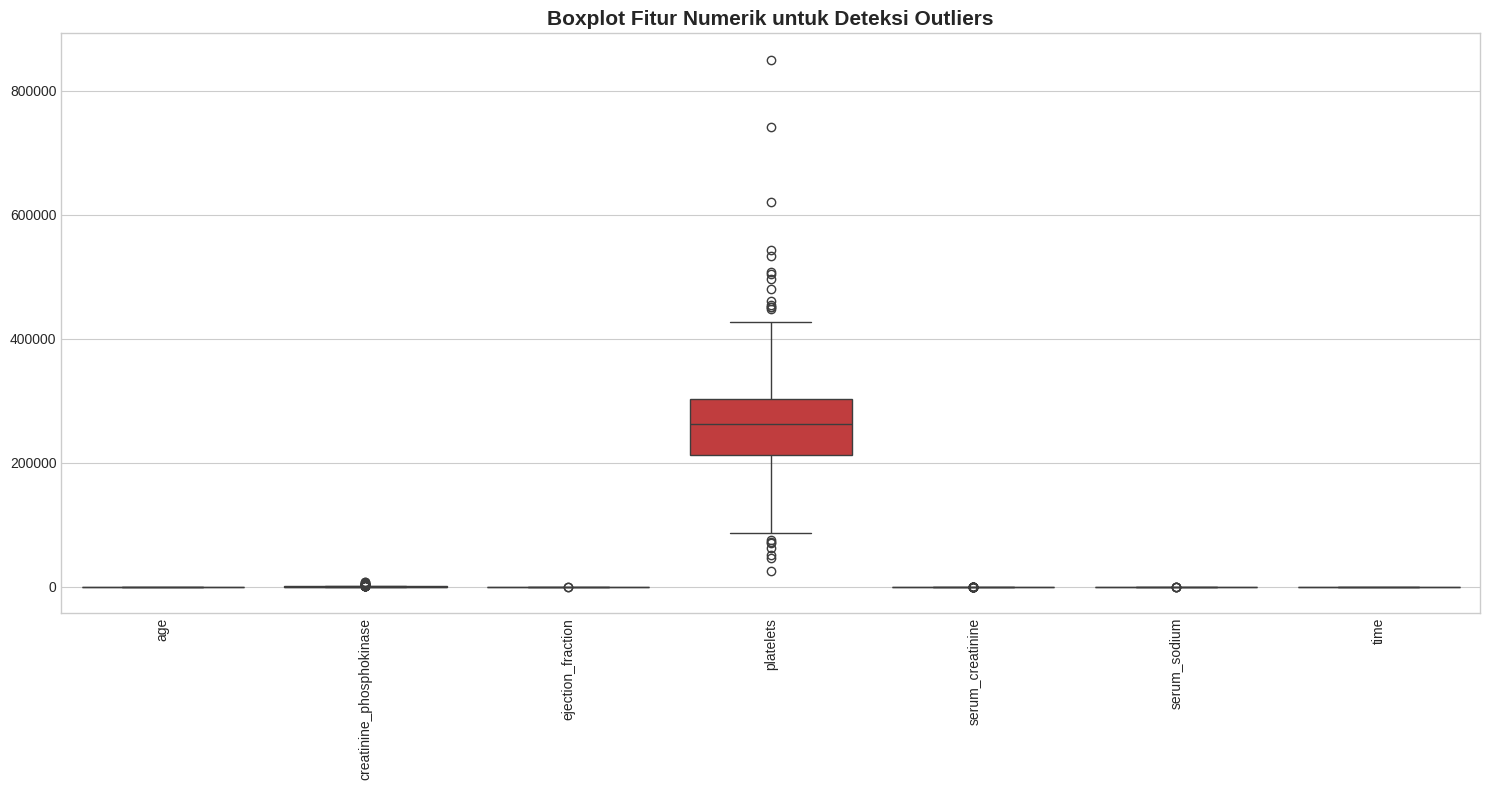

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numerical_features])
plt.title('Boxplot Fitur Numerik untuk Deteksi Outliers', fontsize=15, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Membuat salinan dataset
df_processed = df.copy()

## **Penanganan outlier dengan capping (winsorization)**



--- Penanganan Outliers ---
Outliers pada creatinine_phosphokinase ditangani dengan capping (winsorization)
Outliers pada platelets ditangani dengan capping (winsorization)
Outliers pada serum_creatinine ditangani dengan capping (winsorization)


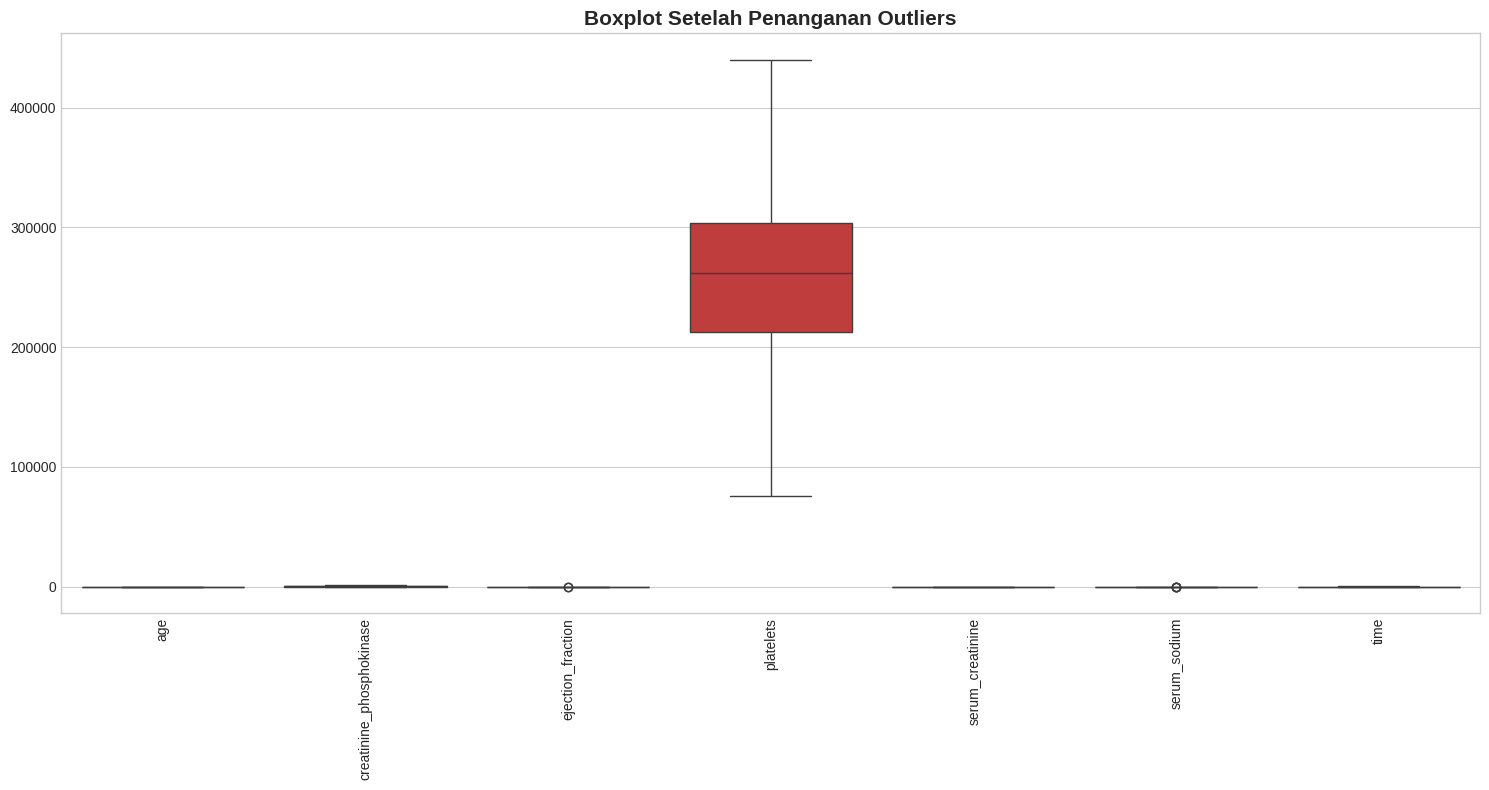

In [ ]:
print("\n--- Penanganan Outliers ---")
# Kita hanya akan menangani outlier pada fitur yang sangat menceng
outlier_features = ['creatinine_phosphokinase', 'platelets', 'serum_creatinine']
for feature in outlier_features:
    Q1 = df_processed[feature].quantile(0.25)
    Q3 = df_processed[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    df_processed[feature] = np.where(df_processed[feature] < lower_bound, lower_bound, df_processed[feature])
    df_processed[feature] = np.where(df_processed[feature] > upper_bound, upper_bound, df_processed[feature])

    print(f"Outliers pada {feature} ditangani dengan capping (winsorization)")

# Visualisasi hasil penanganan outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_processed[numerical_features])
plt.title('Boxplot Setelah Penanganan Outliers', fontsize=15, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('after_outliers_treatment.png', dpi=300, bbox_inches='tight')
plt.show()

## **Feature Scaling**


In [ ]:
print("\n--- Feature Scaling ---")
# Membuat X (fitur) dan y (target)
X = df_processed.drop('DEATH_EVENT', axis=1)
y = df_processed['DEATH_EVENT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Ukuran data training: {X_train.shape}")
print(f"Ukuran data testing: {X_test.shape}")
print(f"Distribusi target di data training: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Distribusi target di data testing: {pd.Series(y_test).value_counts().to_dict()}")



--- Feature Scaling ---
Ukuran data training: (239, 12)
Ukuran data testing: (60, 12)
Distribusi target di data training: {0: 162, 1: 77}
Distribusi target di data testing: {0: 41, 1: 19}


## **Standardisasi fitur numerik**


In [ ]:
print("\nStandardisasi fitur numerik...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame untuk kemudahan penggunaan
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("5 sampel data training setelah standardisasi:")
print(X_train_scaled.head())


Standardisasi fitur numerik...
5 sampel data training setelah standardisasi:
        age   anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0 -0.269050  1.110696                 -0.085829 -0.900337           0.176528   
1 -0.706883 -0.900337                 -0.944468  1.110696           1.847425   
2  1.219579 -0.900337                  0.377887 -0.900337          -1.494369   
3  0.256348 -0.900337                 -0.740637 -0.900337          -1.076645   
4 -1.407414 -0.900337                  0.377887 -0.900337          -1.494369   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium       sex  \
0            -0.770281  -1.176330         -0.518252      0.559915 -1.333818   
1            -0.770281   1.347665         -0.975140     -0.345802  0.749728   
2             1.298227   0.073295          1.537743     -1.477949  0.749728   
3            -0.770281  -0.161783          2.108853     -0.345802  0.749728   
4             1.298227  -1.646486          0.8

# **IMPLEMENTASI MODEL**

In [ ]:
# Fungsi untuk evaluasi model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Fit model
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Probabilitas untuk ROC curve (jika model mendukung)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        has_predict_proba = True
    except:
        has_predict_proba = False

    # Metrik evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Print hasil
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Visualization of confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bertahan', 'Meninggal'],
                yticklabels=['Bertahan', 'Meninggal'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=15, fontweight='bold')
    plt.xlabel('Prediksi', fontsize=12)
    plt.ylabel('Aktual', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # ROC Curve dan AUC (jika model mendukung predict_proba)
    if has_predict_proba:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title(f'ROC Curve - {model_name}', fontsize=15, fontweight='bold')
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.savefig(f'roc_curve_{model_name.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Precision-Recall Curve
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
        average_precision = average_precision_score(y_test, y_prob)

        plt.figure(figsize=(8, 6))
        plt.plot(recall_curve, precision_curve, label=f'AP = {average_precision:.4f}')
        plt.xlabel('Recall', fontsize=12)
        plt.ylabel('Precision', fontsize=12)
        plt.title(f'Precision-Recall Curve - {model_name}', fontsize=15, fontweight='bold')
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.savefig(f'pr_curve_{model_name.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
        plt.show()

    return {
        'model': model,
        'name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc_score if has_predict_proba else None
    }

## **MODEL SECTION**

### **1. Logistic Regression**


1. LOGISTIC REGRESSION
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation score: 0.7530

--- Logistic Regression ---
Accuracy: 0.8167
Precision: 0.8333
Recall: 0.5263
F1-score: 0.6452


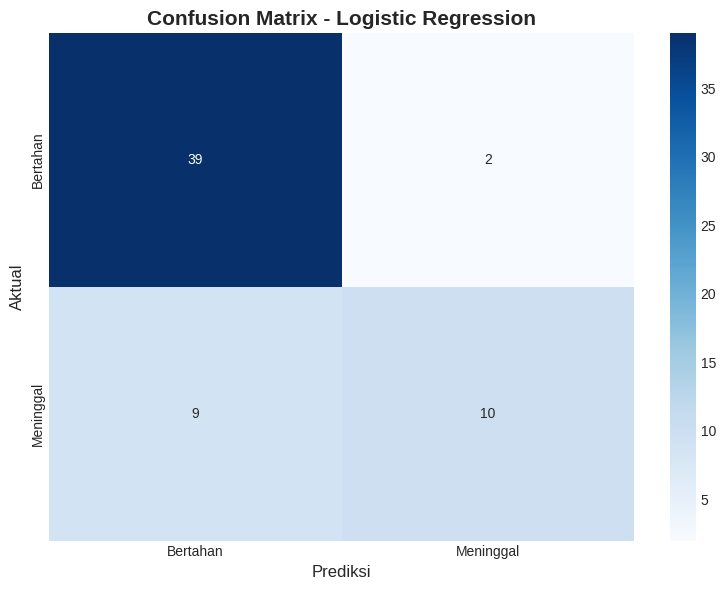


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.88        41
           1       0.83      0.53      0.65        19

    accuracy                           0.82        60
   macro avg       0.82      0.74      0.76        60
weighted avg       0.82      0.82      0.80        60



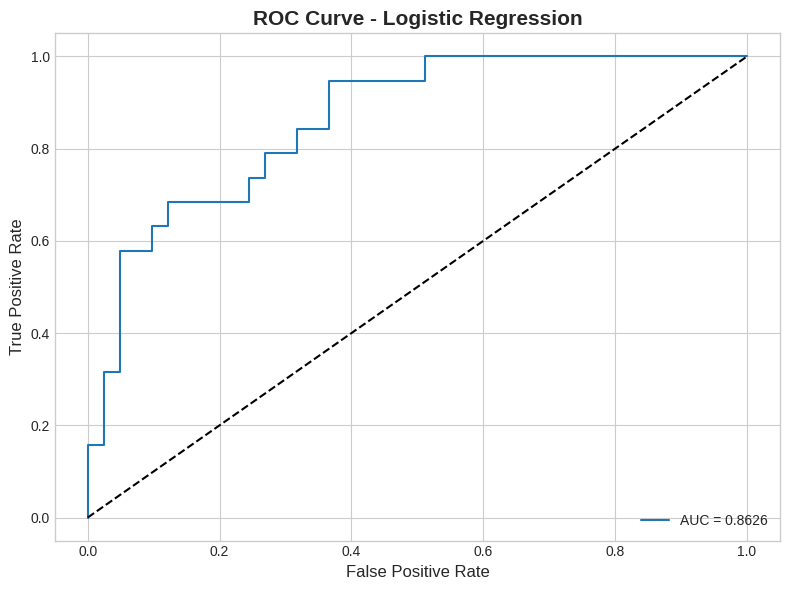

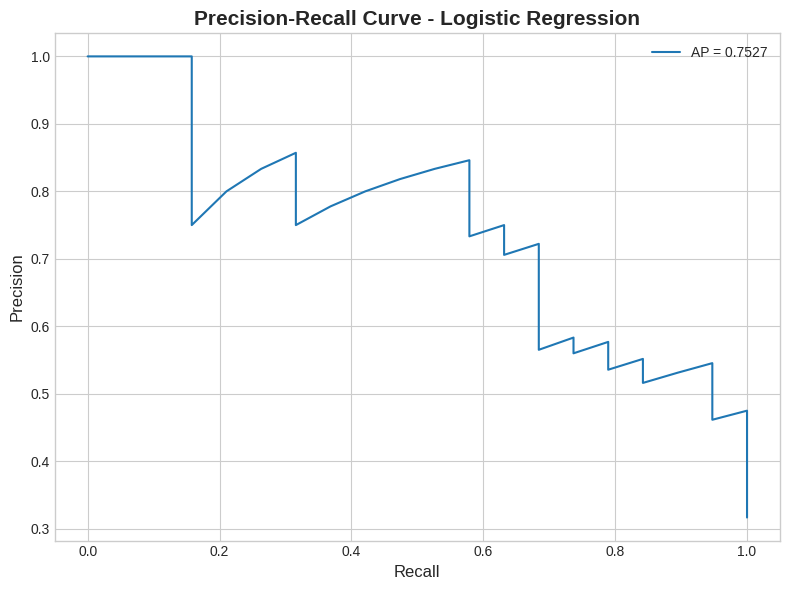

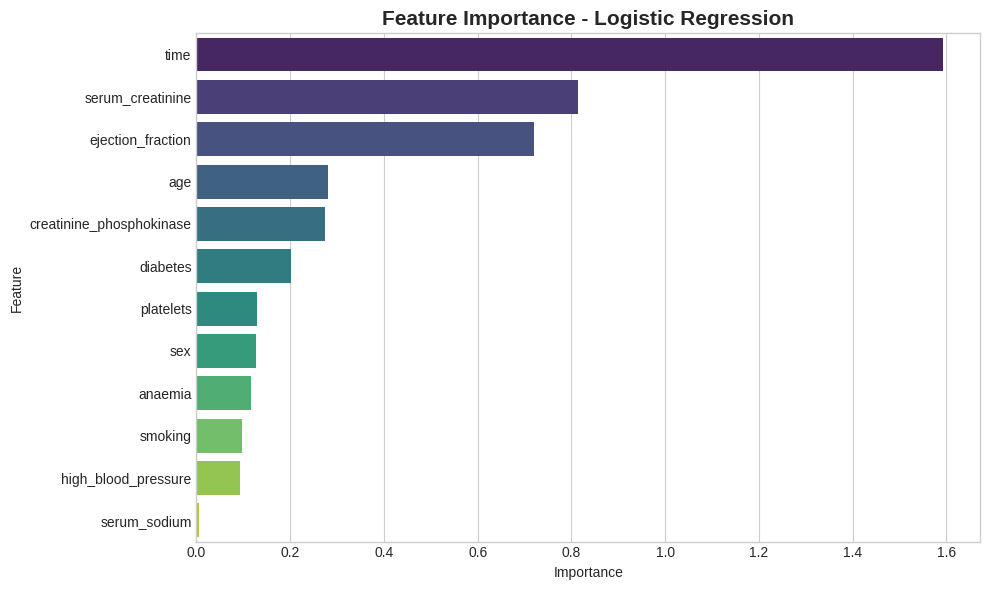

In [ ]:
print("\n1. LOGISTIC REGRESSION")
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': [100, 500, 1000]
}

# Tidak semua kombinasi parameter valid, jadi kita sesuaikan:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [1000]
}

lr_cv = GridSearchCV(LogisticRegression(random_state=42),
                    param_grid_lr,
                    cv=5,
                    scoring='f1',
                    n_jobs=-1,
                    verbose=1)
lr_cv.fit(X_train_scaled, y_train)

print(f"Best parameters: {lr_cv.best_params_}")
print(f"Best cross-validation score: {lr_cv.best_score_:.4f}")

best_lr = lr_cv.best_estimator_
lr_results = evaluate_model(best_lr, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

if best_lr.get_params()['penalty'] is not None:
    plt.figure(figsize=(10, 6))
    lr_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': np.abs(best_lr.coef_[0])
    }).sort_values('Importance', ascending=False)

    sns.barplot(x='Importance', y='Feature', data=lr_importance, palette='viridis')
    plt.title('Feature Importance - Logistic Regression', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance_lr.png', dpi=300, bbox_inches='tight')
    plt.show()

### **2. K-Nearest Neighbors**



2. K-NEAREST NEIGHBORS
Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Best parameters: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best cross-validation score: 0.5818

--- K-Nearest Neighbors ---
Accuracy: 0.7167
Precision: 0.6000
Recall: 0.3158
F1-score: 0.4138


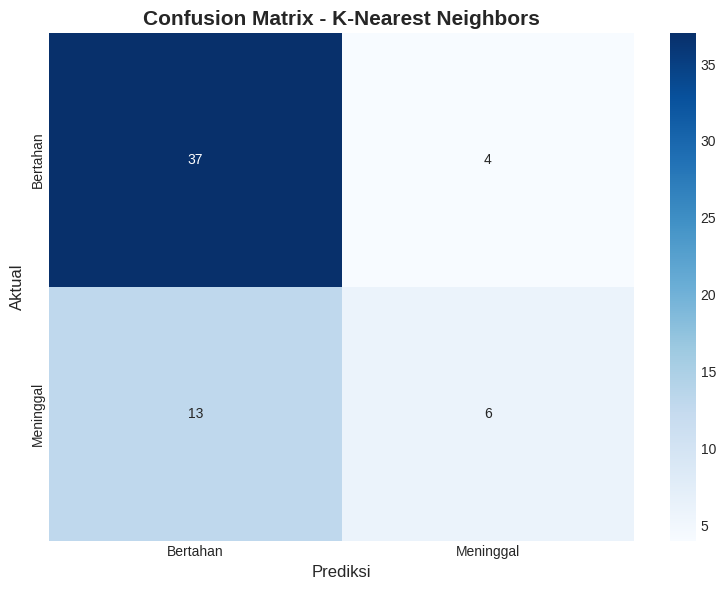


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.90      0.81        41
           1       0.60      0.32      0.41        19

    accuracy                           0.72        60
   macro avg       0.67      0.61      0.61        60
weighted avg       0.70      0.72      0.69        60



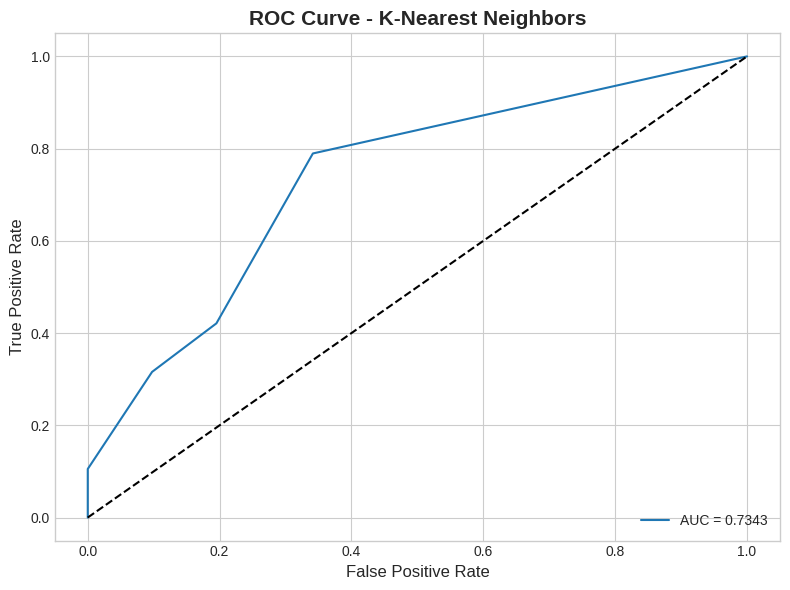

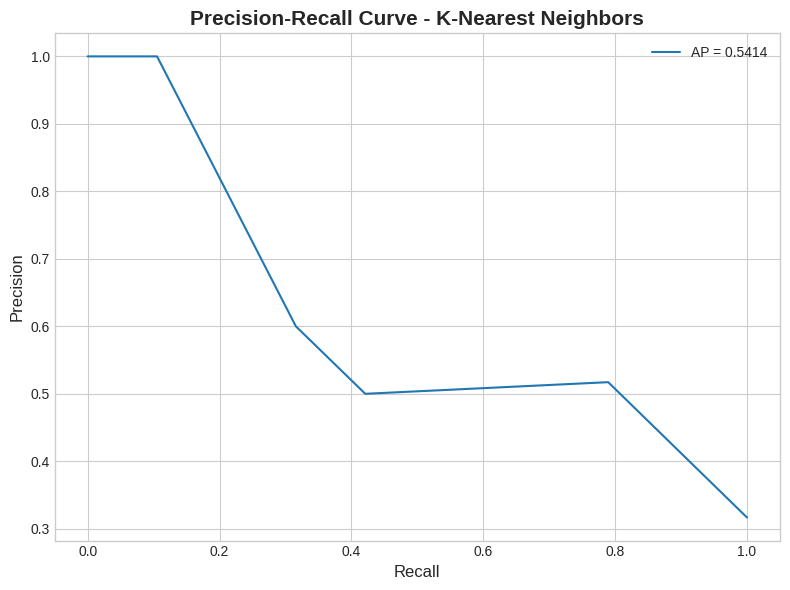

In [ ]:
print("\n2. K-NEAREST NEIGHBORS")
param_grid_knn = {
    'n_neighbors': list(range(1, 31, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

knn_cv = GridSearchCV(KNeighborsClassifier(),
                     param_grid_knn,
                     cv=5,
                     scoring='f1',
                     n_jobs=-1,
                     verbose=1)
knn_cv.fit(X_train_scaled, y_train)

print(f"Best parameters: {knn_cv.best_params_}")
print(f"Best cross-validation score: {knn_cv.best_score_:.4f}")

best_knn = knn_cv.best_estimator_
knn_results = evaluate_model(best_knn, X_train_scaled, X_test_scaled, y_train, y_test, "K-Nearest Neighbors")


### **3. Support Vector Machine**



3. SUPPORT VECTOR MACHINE
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation score: 0.7571

--- Support Vector Machine ---
Accuracy: 0.8167
Precision: 0.8333
Recall: 0.5263
F1-score: 0.6452


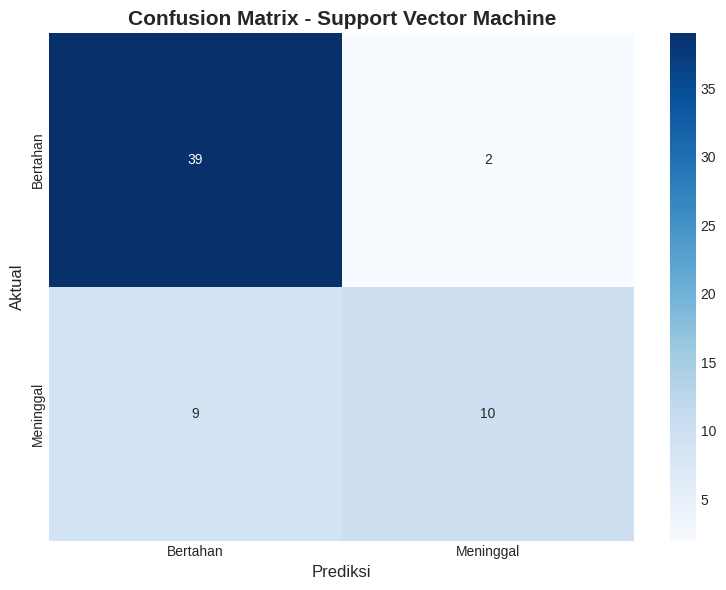


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.88        41
           1       0.83      0.53      0.65        19

    accuracy                           0.82        60
   macro avg       0.82      0.74      0.76        60
weighted avg       0.82      0.82      0.80        60



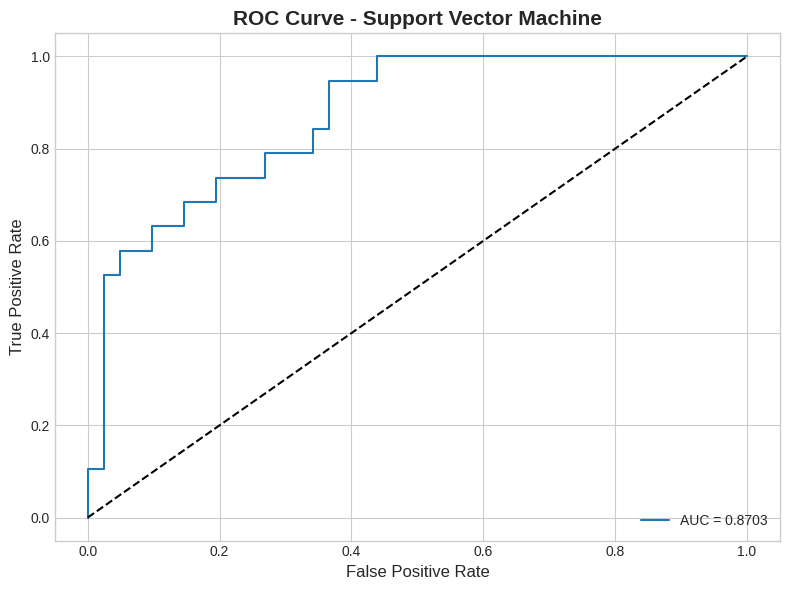

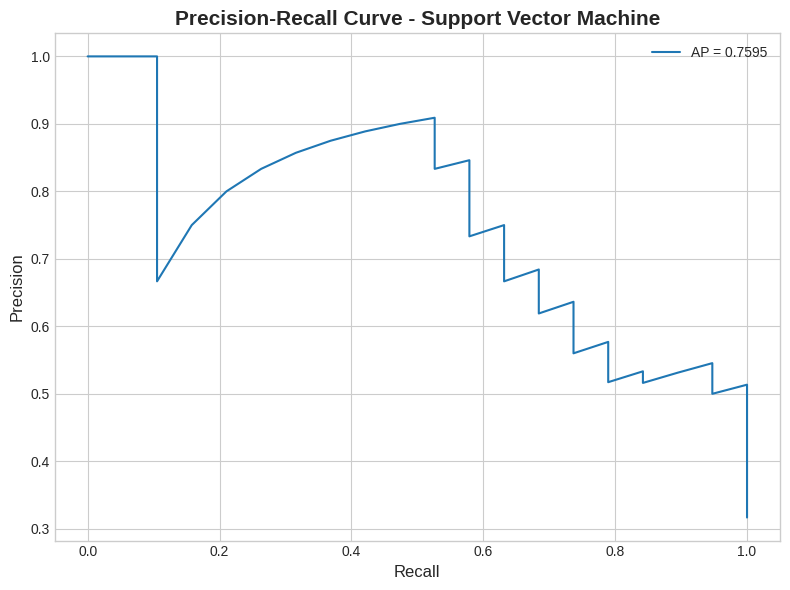

In [ ]:
print("\n3. SUPPORT VECTOR MACHINE")
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid', 'linear']
}

svm_cv = GridSearchCV(SVC(probability=True, random_state=42),
                     param_grid_svm,
                     cv=5,
                     scoring='f1',
                     n_jobs=-1,
                     verbose=1)
svm_cv.fit(X_train_scaled, y_train)

print(f"Best parameters: {svm_cv.best_params_}")
print(f"Best cross-validation score: {svm_cv.best_score_:.4f}")

best_svm = svm_cv.best_estimator_
svm_results = evaluate_model(best_svm, X_train_scaled, X_test_scaled, y_train, y_test, "Support Vector Machine")


### **4. Naive Bayes**



4. NAIVE BAYES

--- Naive Bayes ---
Accuracy: 0.7833
Precision: 0.7143
Recall: 0.5263
F1-score: 0.6061


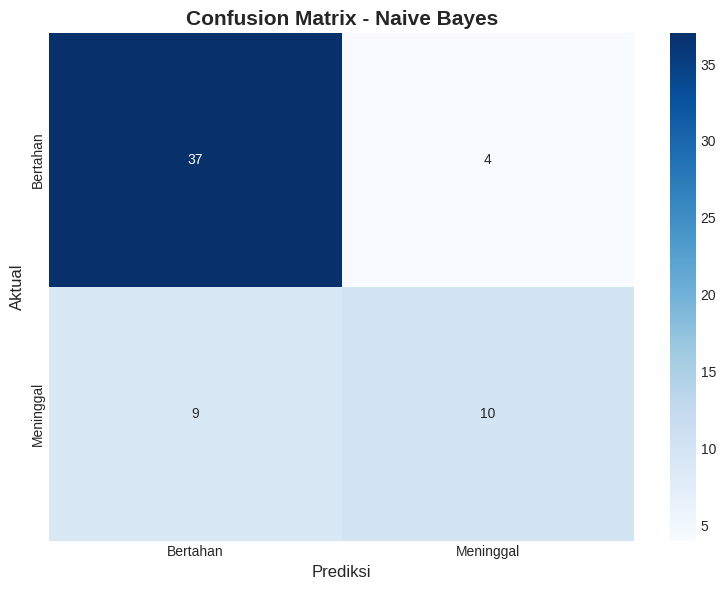


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        41
           1       0.71      0.53      0.61        19

    accuracy                           0.78        60
   macro avg       0.76      0.71      0.73        60
weighted avg       0.78      0.78      0.77        60



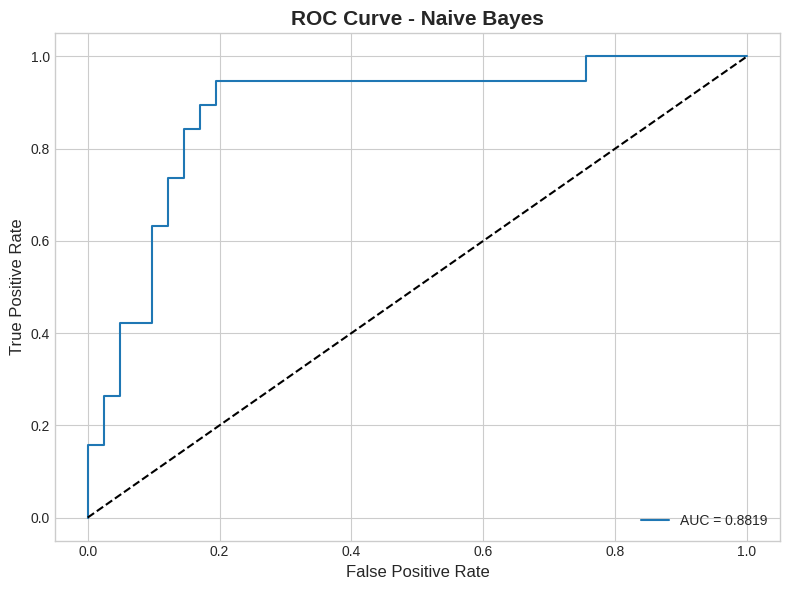

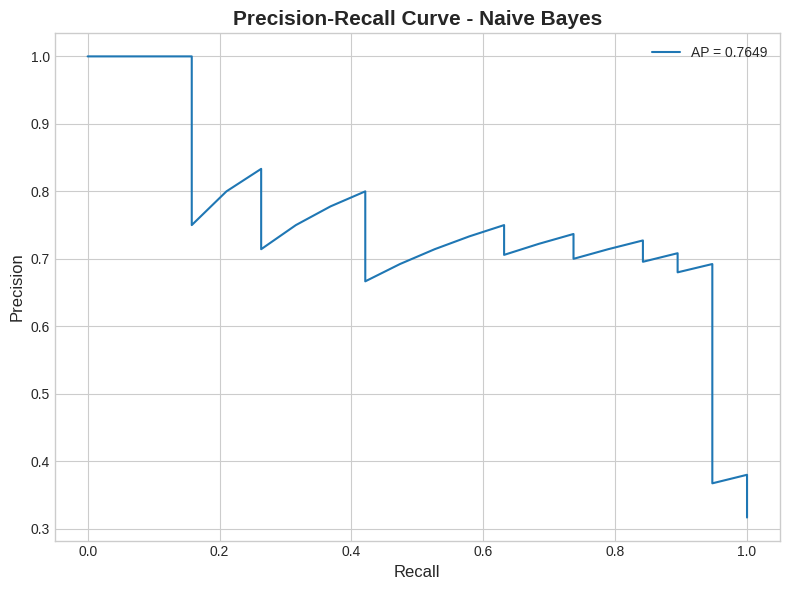

In [ ]:
print("\n4. NAIVE BAYES")

nb_model = GaussianNB()
nb_results = evaluate_model(nb_model, X_train_scaled, X_test_scaled, y_train, y_test, "Naive Bayes")

### **5. Decision Tree**



5. DECISION TREE
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score: 0.6892

--- Decision Tree ---
Accuracy: 0.7833
Precision: 0.7143
Recall: 0.5263
F1-score: 0.6061


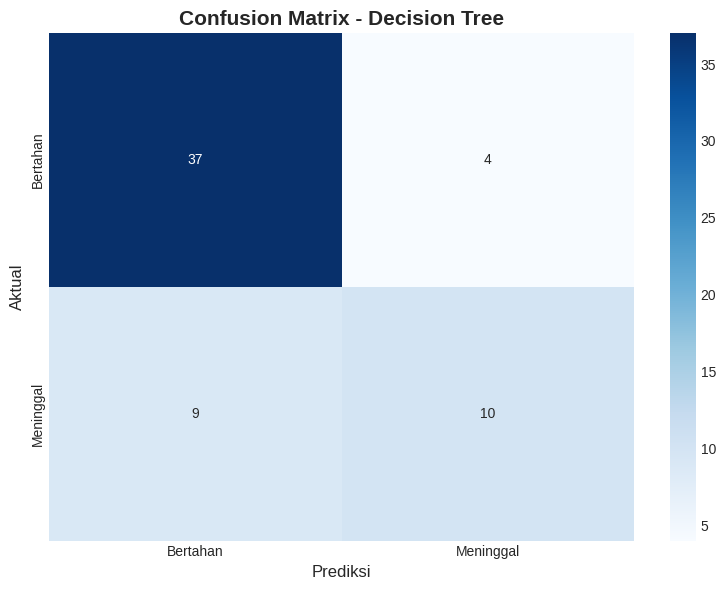


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        41
           1       0.71      0.53      0.61        19

    accuracy                           0.78        60
   macro avg       0.76      0.71      0.73        60
weighted avg       0.78      0.78      0.77        60



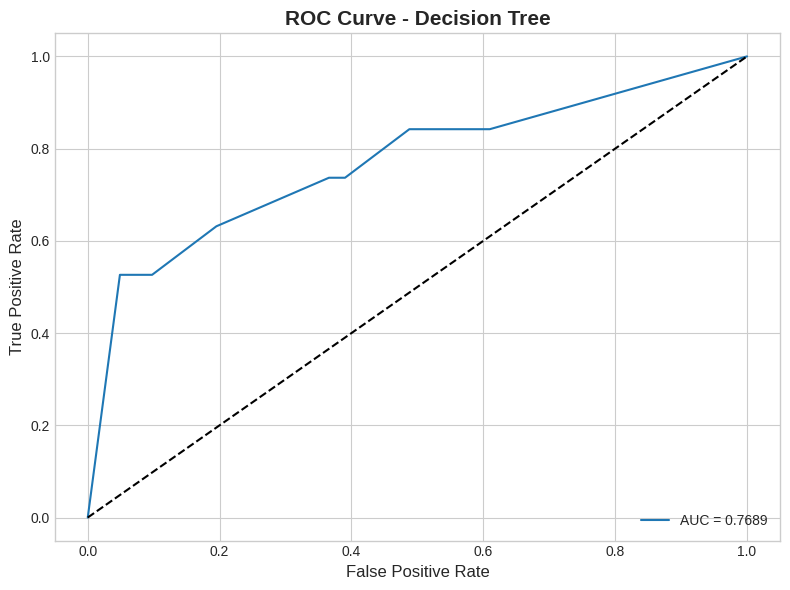

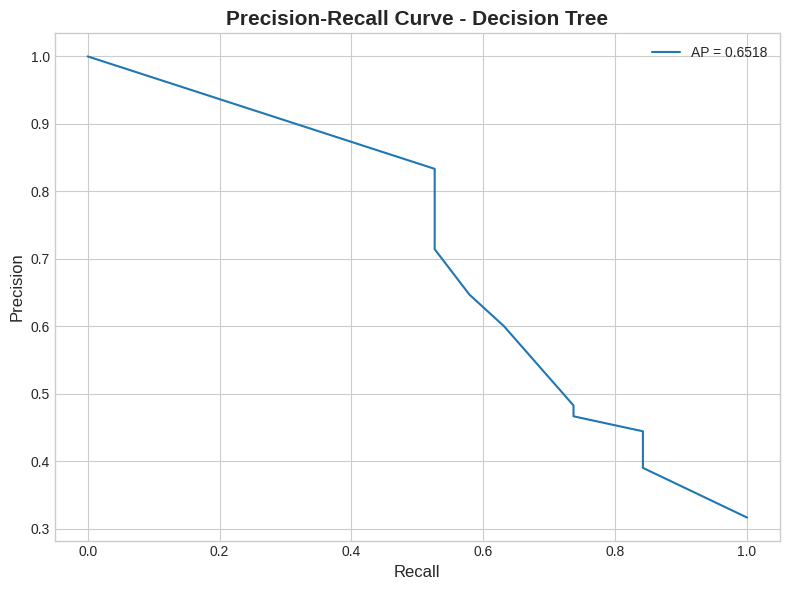

In [ ]:
print("\n5. DECISION TREE")
# Hyperparameter tuning
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

dt_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid_dt,
                    cv=5,
                    scoring='f1',
                    n_jobs=-1,
                    verbose=1)
dt_cv.fit(X_train_scaled, y_train)

print(f"Best parameters: {dt_cv.best_params_}")
print(f"Best cross-validation score: {dt_cv.best_score_:.4f}")

# Evaluate best Decision Tree model
best_dt = dt_cv.best_estimator_
dt_results = evaluate_model(best_dt, X_train_scaled, X_test_scaled, y_train, y_test, "Decision Tree")


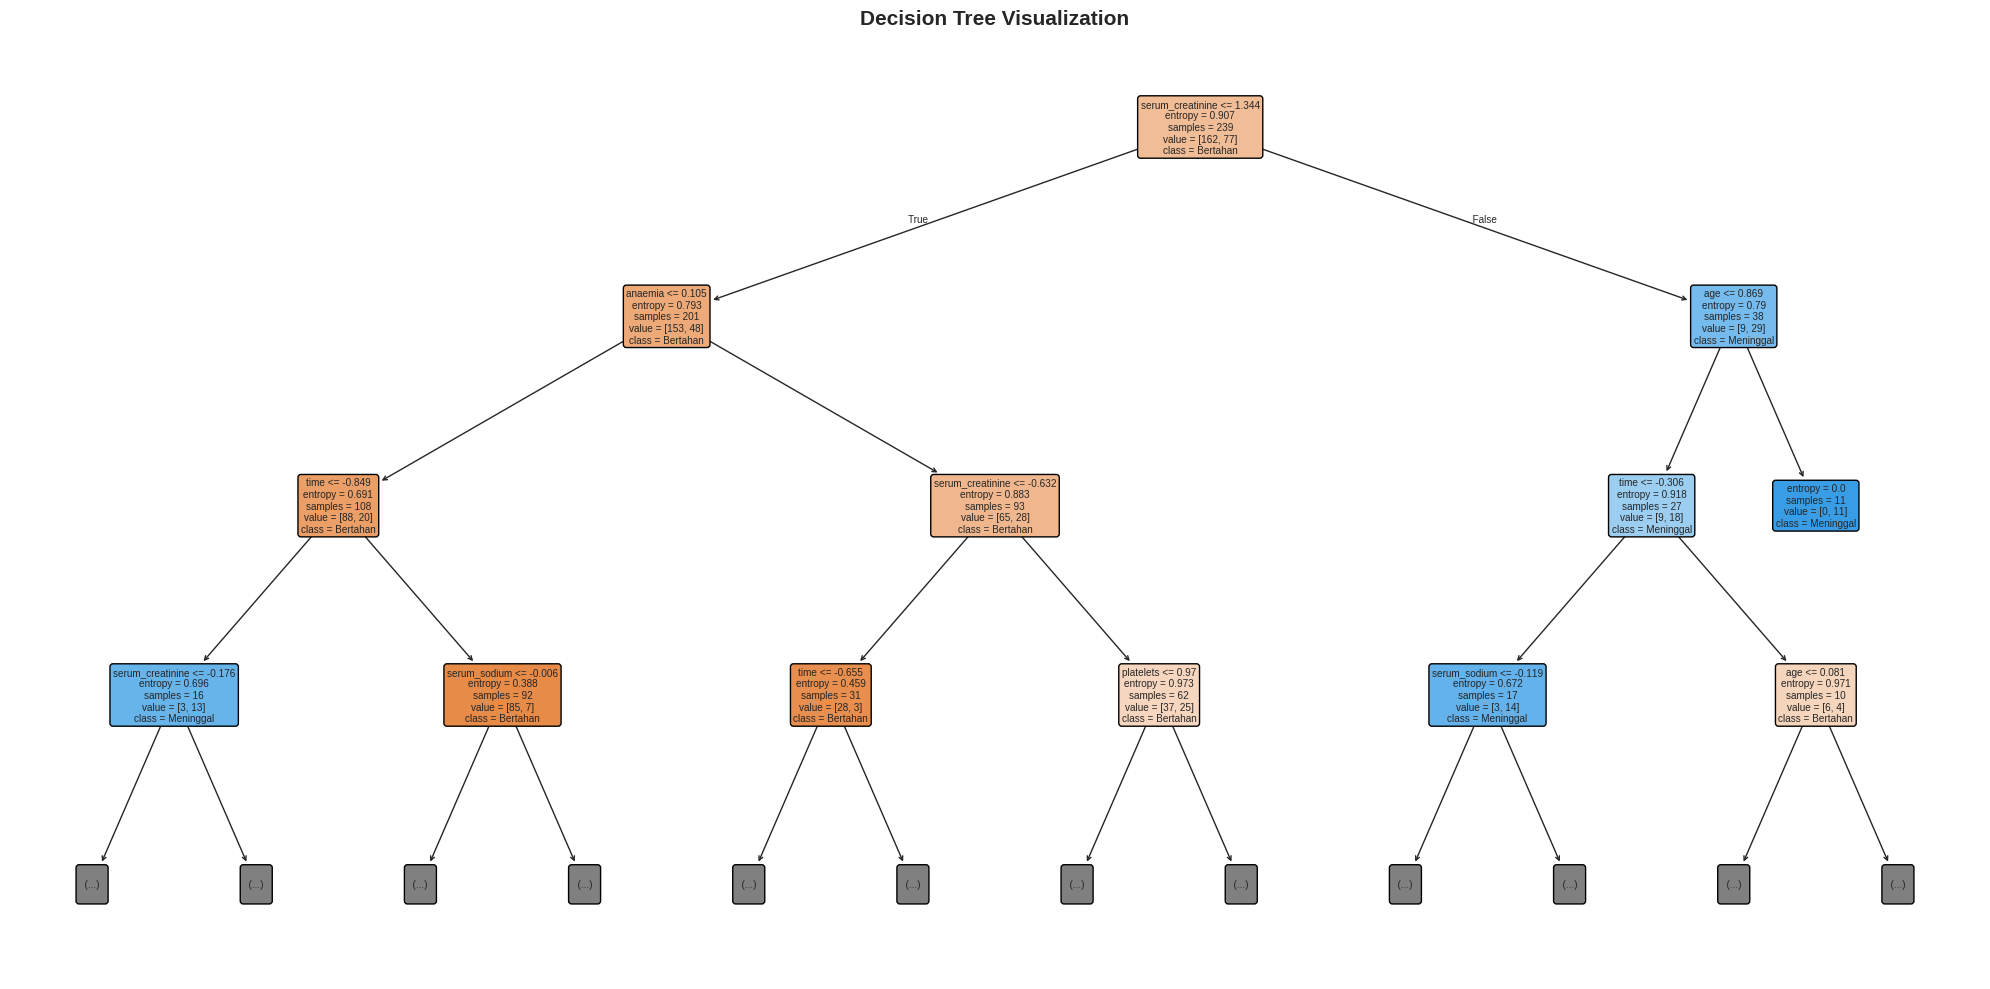

In [ ]:

# Visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(best_dt,
          feature_names=X_train.columns,
          class_names=['Bertahan', 'Meninggal'],
          filled=True,
          rounded=True,
          max_depth=3)  # Limit depth for better visualization
plt.title('Decision Tree Visualization', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

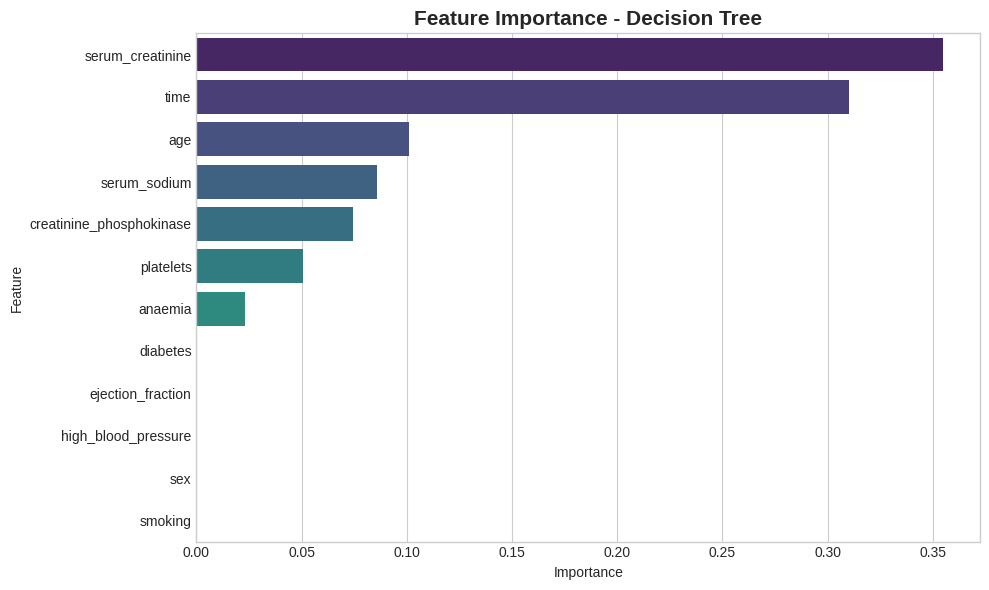

In [ ]:
# Feature importance for decision tree
plt.figure(figsize=(10, 6))
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=dt_importance, palette='viridis')
plt.title('Feature Importance - Decision Tree', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_dt.png', dpi=300, bbox_inches='tight')
plt.show()

## **PERBANDINGAN MODEL**


In [ ]:
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

all_results = [lr_results, knn_results, svm_results, nb_results, dt_results]

comparison_df = pd.DataFrame({
    'Model': [result['name'] for result in all_results],
    'Accuracy': [result['accuracy'] for result in all_results],
    'Precision': [result['precision'] for result in all_results],
    'Recall': [result['recall'] for result in all_results],
    'F1-Score': [result['f1'] for result in all_results],
    'AUC': [result['auc'] for result in all_results if result['auc'] is not None]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\nModel Performance Comparison:")
print(comparison_df)


MODEL COMPARISON

Model Performance Comparison:
                    Model  Accuracy  Precision    Recall  F1-Score       AUC
0     Logistic Regression  0.816667   0.833333  0.526316  0.645161  0.862644
1  Support Vector Machine  0.816667   0.833333  0.526316  0.645161  0.870347
2             Naive Bayes  0.783333   0.714286  0.526316  0.606061  0.881900
3           Decision Tree  0.783333   0.714286  0.526316  0.606061  0.768935
4     K-Nearest Neighbors  0.716667   0.600000  0.315789  0.413793  0.734275


## **Visualize model comparison**


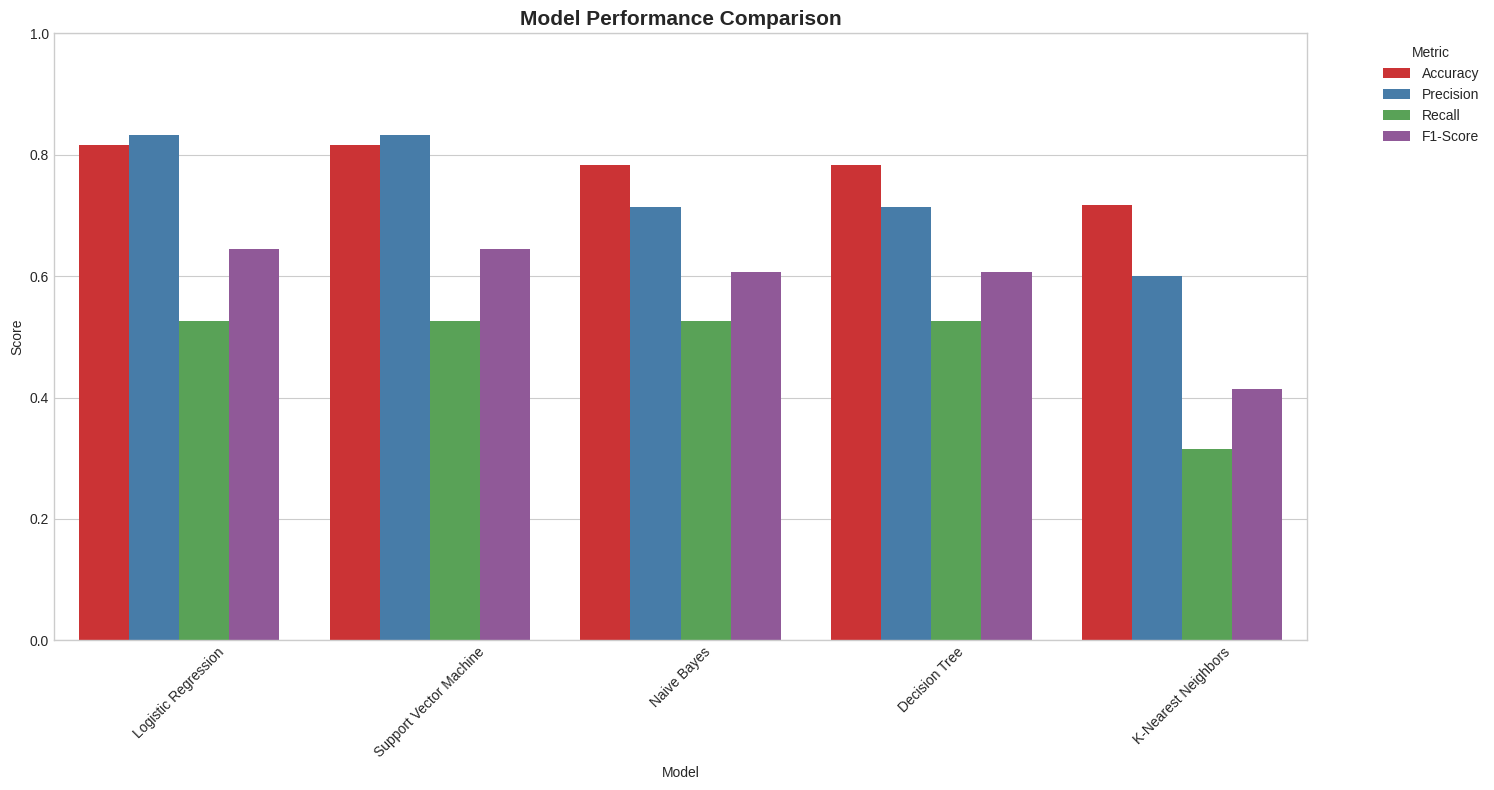

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison_df_melted = pd.melt(comparison_df,
                              id_vars=['Model'],
                              value_vars=metrics,
                              var_name='Metric',
                              value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=comparison_df_melted, palette='Set1')
plt.title('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



## **Compare ROC curves**


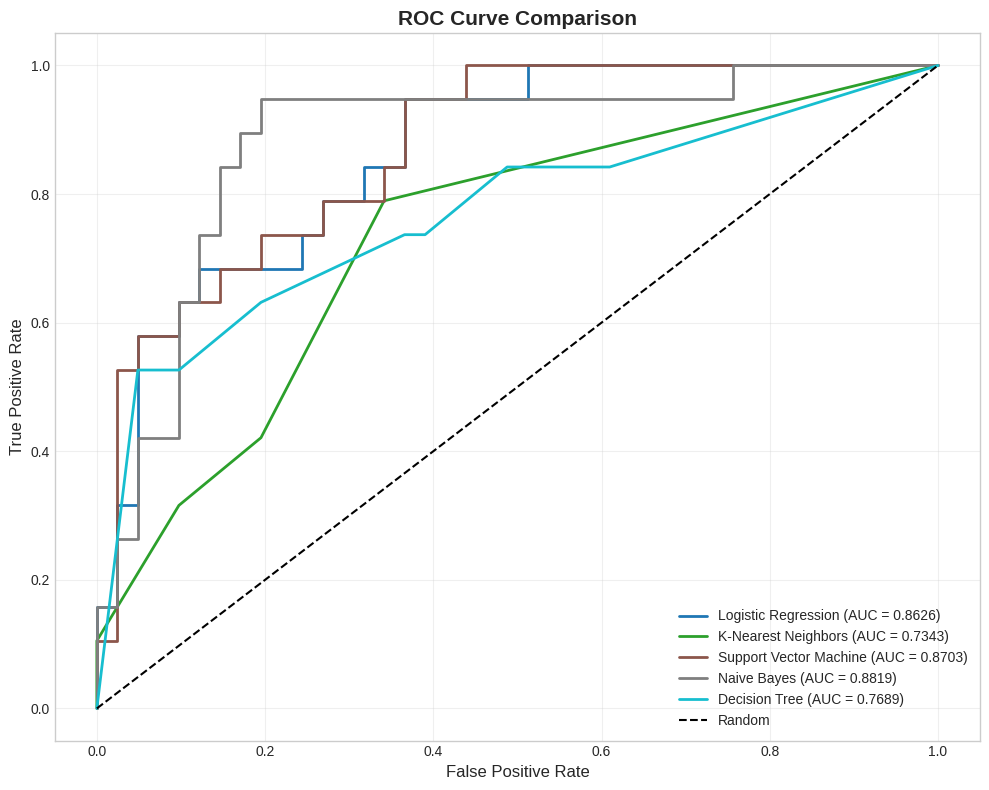

In [ ]:
plt.figure(figsize=(10, 8))

# Get colors from a colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for i, result in enumerate(all_results):
    model = result['model']
    model_name = result['name']

    # Skip if model doesn't support predict_proba
    try:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', color=colors[i], linewidth=2)
    except:
        continue

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=15, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



## **Feature Importance Comparison using Permutation Importance**


In [ ]:
# Feature Importance Comparison using Permutation Importance
print("\n--- Feature Importance Analysis ---")
# Get the best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = None
for result in all_results:
    if result['name'] == best_model_name:
        best_model = result['model']
        break

# Calculate permutation importance
perm_importance = permutation_importance(best_model, X_test_scaled, y_test,
                                        n_repeats=10, random_state=42, n_jobs=-1)

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Important Features (using {best_model_name}):")
print(importance_df.head(10))



--- Feature Importance Analysis ---

Top 10 Important Features (using Logistic Regression):
                Feature  Importance       Std
11                 time    0.160000  0.040961
4     ejection_fraction    0.068333  0.022913
7      serum_creatinine    0.026667  0.023805
0                   age    0.021667  0.019791
9                   sex    0.008333  0.008333
1               anaemia    0.006667  0.008165
6             platelets    0.005000  0.010672
10              smoking    0.003333  0.014530
5   high_blood_pressure    0.001667  0.011667
8          serum_sodium    0.000000  0.000000


## **Visualize feature importance**


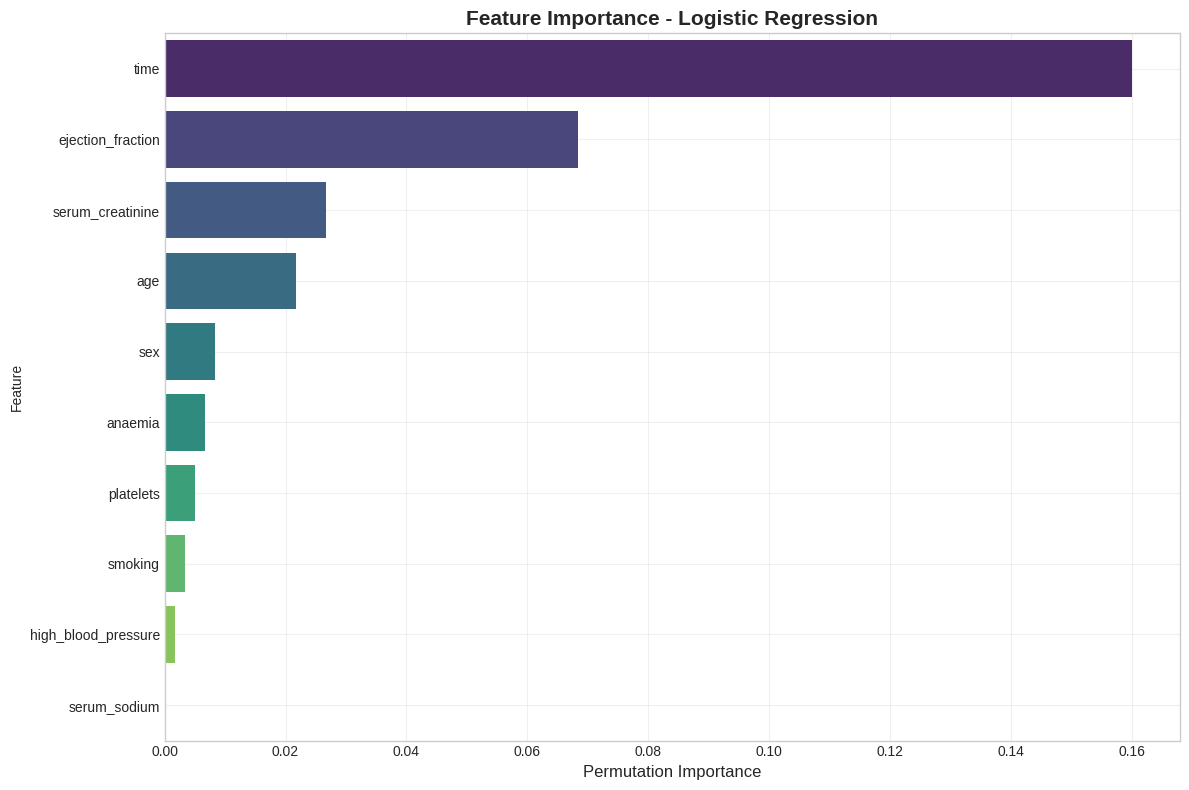

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title(f'Feature Importance - {best_model_name}', fontsize=15, fontweight='bold')
plt.xlabel('Permutation Importance', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_permutation.png', dpi=300, bbox_inches='tight')
plt.show()

# **KESIMPULAN & INTERPRETASI**


In [ ]:
print("\n" + "="*80)
print("CONCLUSION AND CLINICAL INTERPRETATION")
print("="*80)

# Best model summary
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_f1 = comparison_df.loc[best_model_idx, 'F1-Score']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\nModel Terbaik: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"F1-Score: {best_f1:.4f}")

# Top features analysis
print("\nFaktor Risiko Paling Berpengaruh:")
for idx, row in importance_df.head(5).iterrows():
    feature = row['Feature']
    importance = row['Importance']

    # Get average value for survivors vs deceased
    avg_survive = df[df['DEATH_EVENT'] == 0][feature].mean()
    avg_death = df[df['DEATH_EVENT'] == 1][feature].mean()

    # Interpret direction of influence
    if feature in categorical_features:
        if avg_death > avg_survive:
            direction = "meningkatkan"
        else:
            direction = "menurunkan"

        print(f"- {feature}: {importance:.4f} - Keberadaannya {direction} risiko kematian")
    else:
        if avg_death > avg_survive:
            direction = "lebih tinggi"
        else:
            direction = "lebih rendah"

        print(f"- {feature}: {importance:.4f} - Nilai {direction} pada pasien yang meninggal")
        print(f"  (Rata-rata pada pasien yang bertahan: {avg_survive:.2f}, meninggal: {avg_death:.2f})")

# Clinical implications
print("\nImplikasi Klinis:")
print("1. Berdasarkan analisis model, faktor-faktor berikut perlu diperhatikan dalam penanganan pasien:")

# Age analysis if it's important
if 'age' in importance_df.head(10)['Feature'].values:
    print("   - Usia pasien yang lebih tua memiliki risiko kematian lebih tinggi")
    print(f"   - Usia rata-rata pasien yang bertahan: {df[df['DEATH_EVENT'] == 0]['age'].mean():.1f} tahun")
    print(f"   - Usia rata-rata pasien yang meninggal: {df[df['DEATH_EVENT'] == 1]['age'].mean():.1f} tahun")

# Serum creatinine analysis if it's important
if 'serum_creatinine' in importance_df.head(10)['Feature'].values:
    print("   - Kadar serum kreatinin yang tinggi adalah prediktor kuat kematian")
    print(f"   - Serum kreatinin rata-rata pasien yang bertahan: {df[df['DEATH_EVENT'] == 0]['serum_creatinine'].mean():.2f} mg/dL")
    print(f"   - Serum kreatinin rata-rata pasien yang meninggal: {df[df['DEATH_EVENT'] == 1]['serum_creatinine'].mean():.2f} mg/dL")

# Ejection fraction analysis if it's important
if 'ejection_fraction' in importance_df.head(10)['Feature'].values:
    print("   - Ejection fraction yang rendah terkait dengan peningkatan risiko kematian")
    print(f"   - Ejection fraction rata-rata pasien yang bertahan: {df[df['DEATH_EVENT'] == 0]['ejection_fraction'].mean():.2f}%")
    print(f"   - Ejection fraction rata-rata pasien yang meninggal: {df[df['DEATH_EVENT'] == 1]['ejection_fraction'].mean():.2f}%")

# Add other important factors
for feature in importance_df.head(5)['Feature'].values:
    if feature not in ['age', 'serum_creatinine', 'ejection_fraction'] and feature in feature_descriptions:
        # Get description
        description = feature_descriptions.get(feature, feature)
        print(f"   - {description} juga merupakan faktor penting")

print("\n2. Rekomendasi Penanganan:")
print("   - Pemantauan lebih ketat pada pasien dengan faktor risiko tinggi")
print("   - Intervensi medis yang tepat untuk kondisi yang teridentifikasi sebagai faktor risiko")
print("   - Pendekatan personalisasi pengobatan berdasarkan profil risiko individu")

print("\n3. Keterbatasan Model:")
print("   - Dataset relatif kecil (299 pasien), dapat mempengaruhi generalisasi model")
print("   - Beberapa fitur mungkin memiliki hubungan non-linear yang kompleks")
print("   - Hasil prediksi harus diinterpretasikan bersama dengan penilaian klinis")

print("\n4. Rekomendasi Pengembangan:")
print("   - Mengumpulkan lebih banyak data untuk meningkatkan performa model")
print("   - Menambahkan fitur klinis lain yang relevan")
print("   - Mengembangkan sistem peringatan dini untuk pasien berisiko tinggi")

print("\nTerima kasih telah menggunakan model prediksi Heart Failure. Semoga hasil analisis ini dapat membantu dalam pengambilan keputusan klinis yang lebih baik.")


CONCLUSION AND CLINICAL INTERPRETATION

Model Terbaik: Logistic Regression
Accuracy: 0.8167
F1-Score: 0.6452

Faktor Risiko Paling Berpengaruh:
- time: 0.1600 - Nilai lebih rendah pada pasien yang meninggal
  (Rata-rata pada pasien yang bertahan: 158.34, meninggal: 70.89)
- ejection_fraction: 0.0683 - Nilai lebih rendah pada pasien yang meninggal
  (Rata-rata pada pasien yang bertahan: 40.27, meninggal: 33.47)
- serum_creatinine: 0.0267 - Nilai lebih tinggi pada pasien yang meninggal
  (Rata-rata pada pasien yang bertahan: 1.18, meninggal: 1.84)
- age: 0.0217 - Nilai lebih tinggi pada pasien yang meninggal
  (Rata-rata pada pasien yang bertahan: 58.76, meninggal: 65.22)
- sex: 0.0083 - Keberadaannya menurunkan risiko kematian

Implikasi Klinis:
1. Berdasarkan analisis model, faktor-faktor berikut perlu diperhatikan dalam penanganan pasien:
   - Usia pasien yang lebih tua memiliki risiko kematian lebih tinggi
   - Usia rata-rata pasien yang bertahan: 58.8 tahun
   - Usia rata-rata pasi